In [1]:
# Set up

import pandas as pd
import numpy as np
from scipy import interpolate
import copy
import os
import sys
import gc
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from matplotlib.colors import hex2color, rgb2hex
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import datetime

script_path = os.getcwd()

# Years MOT data is available for
MOT_data_years = list(range(2024, 2014, -1)) 

def process_MOT_data(df, fuel):
    print(f"Processing {fuel} data")
    print(f"Starting sample size: {df['vehicle_id'].nunique()} vehicles")
    
    print("Processing MOT data")
    
    # Convert to km
    df['test_mileage'] =  df['test_mileage']*1.61 # km
    df['mileage_per_year'] =  df['mileage_per_year']*1.61 # km


    # Reduce the memory used by the dataset
    print(f"Reducing memory usage - {df.memory_usage().sum() / 1e6:.2f} MB")
    
    # Convert object types to category if there are many repeated values
    for col in df.select_dtypes(include=['object']).columns:
        df[col] = df[col].astype('category')
    # Convert integer columns to the smallest possible integer type
    for col in df.select_dtypes(include=['int']).columns:
        df[col] = pd.to_numeric(df[col], downcast='integer')
    # Convert float columns to the smallest possible float type
    for col in df.select_dtypes(include=['float']).columns:
        df[col] = pd.to_numeric(df[col], downcast='float')
    print(f"Reduced memory usage - {df.memory_usage().sum() / 1e6:.2f} MB")
    
    print(f"Finished sample size: {df['vehicle_id'].nunique()} vehicles")
    return df

def interpolate_data(x_values, y_values, query_point, interpolate_for='x'):
    
    # Convert inputs to numpy arrays if they aren't already
    x = np.array(x_values)
    y = np.array(y_values)
    
    if interpolate_for.lower() == 'x':
        # Create interpolation function for finding y at given x
        f = interpolate.interp1d(x, y, kind='linear', 
                                fill_value='extrapolate')
        return float(f(query_point))
    
    elif interpolate_for.lower() == 'y':
        # Create interpolation function for finding x at given y
        f = interpolate.interp1d(y, x, kind='linear', 
                                fill_value='extrapolate')
        return float(f(query_point))
    
    else:
        raise ValueError("interpolate_for must be either 'x' or 'y'")

def get_fuel_labels(fuel):
    fuel_labels = {
        'car_diesel' : 'Diesel', 
        'car_petrol' : 'Petrol', 
        'car_hev' : 'HEV', 
        'car_bev' : 'BEV',
        'lgv': 'LGV',
        'mcycle' : 'Motorcycle',
        'car_bev_battery_30' : "< 30 kWh",
        'car_bev_battery_60' : "30-60 kWh",
        'car_bev_battery_100' : "> 60 kWh",
        'car_bev_make_TESLA' : "Tesla",
        'car_bev_make_NISSAN' : "Nissan",
        'car_bev_make_RENAULT' : "Renault",
        'car_bev_make_BMW' : "BMW",
        'car_bev_make_KIA' : "Kia",
        'car_bev_make_HYUNDAI' : "Hyundai",
        }
    return  fuel_labels[fuel]

def get_fuel_labels_disag(fuel):
    fuel_labels = {
        'car_diesel' : 'Diesel', 
        'car_petrol' : 'Petrol', 
        'car_hev' : 'HEV', 
        'car_bev' : 'All BEVs',
        'lgv': 'LGV',
        'mcycle' : 'Motorcycle',
        'car_bev_battery_30' : "< 30 kWh",
        'car_bev_battery_60' : "30-60 kWh",
        'car_bev_battery_100' : "> 60 kWh",
        'car_bev_make_TESLA' : "Tesla",
        'car_bev_make_NISSAN' : "Nissan",
        'car_bev_make_RENAULT' : "Renault",
        'car_bev_make_BMW' : "BMW",
        'car_bev_make_KIA' : "Kia",
        'car_bev_make_HYUNDAI' : "Hyundai",
        }
    return  fuel_labels[fuel]

def get_fuel_cut_off_year(fuel):
    fuel_cut_off_year = {
        'car_diesel' : 1994, 
        'car_petrol' : 1994, 
        'car_hev' : 2007, 
        'car_bev' : 2012,
        'lgv': 1994,
        'mcycle' : 1994
        }
    return fuel_cut_off_year[fuel]

def y_fmt(y, pos):
    decades = [1e9, 1e6, 1e3, 1e0, 1e-3, 1e-6, 1e-9 ]
    suffix  = ["G", "M", "k", "" , "m" , "u", "n"  ]
    if y == 0:
        return str(0)
    for i, d in enumerate(decades):
        if np.abs(y) >=d:
            val = y/float(d)
            signf = len(str(val).split(".")[1])
            if signf == 0:
                return '{val:d} {suffix}'.format(val=int(val), suffix=suffix[i])
            else:
                if signf == 1:
                    #print val, signf
                    if str(val).split(".")[1] == "0":
                       return '{val:d} {suffix}'.format(val=int(round(val)), suffix=suffix[i]) 
                tx = "{"+"val:.{signf}f".format(signf = signf) +"} {suffix}"
                return tx.format(val=val, suffix=suffix[i])

def create_colormap(colors, n):
    """
    Create a continuous colormap from a list of hex colors.
    
    Parameters:
        colors (list): List of hex color strings (e.g., ['#FFFF00', '#0000FF'])
        n (int): Number of colors to output
        
    Returns:
        list: List of n hex colors interpolated between input colors
    """
    # Convert hex colors to RGB
    rgb_colors = [hex2color(color) for color in colors]
    
    # Create position array for input colors
    positions = np.linspace(0, 1, len(colors))
    
    # Create position array for output colors
    output_positions = np.linspace(0, 1, n)
    
    # Initialize output RGB arrays
    r = np.interp(output_positions, positions, [color[0] for color in rgb_colors])
    g = np.interp(output_positions, positions, [color[1] for color in rgb_colors])
    b = np.interp(output_positions, positions, [color[2] for color in rgb_colors])
    
    # Convert back to hex
    output_colors = [rgb2hex((r[i], g[i], b[i])) for i in range(n)]
    
    return output_colors

# import matplotlib as mpl
# import shutil

# cache_dir = mpl.get_cachedir()
# if os.path.exists(cache_dir):
#     shutil.rmtree(cache_dir)

plt.rcParams.update({
    # Font
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"], 
    "font.size": 5,               
    "axes.titlesize": 5,
    "axes.labelsize": 5,
    "xtick.labelsize": 5,
    "ytick.labelsize": 5,
    "legend.fontsize": 5,
    "figure.titlesize": 5,

    "axes.linewidth": 0.5,
    "lines.linewidth": 0.75,
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    "xtick.minor.width": 0.4,
    "ytick.minor.width": 0.4,
    
    # PDF/EPS font embedding 
    "pdf.fonttype": 42,            
    "ps.fonttype": 42,
})

In [2]:
# Read in data for figures and scrappage analysis

fuel_filename_lookup = {
    'car_diesel' : "sample_car_diesel_all_years.parquet",
    'car_petrol' : "sample_car_petrol_all_years.parquet",
    'car_hev' : "sample_car_hev_all_years.parquet",
    'car_bev' : "sample_car_bev_all_years.parquet",
    }

fuel_data = {}

# Only use cols we need for the mileage & scrappage analysis
cols = [
    "vehicle_id", "test_date", "test_mileage", "mileage_per_year", "first_use_year", "battery capacity (kWh)", "fuel efficiency Wh/mi",
    "make", "age_year_rounded", "test_year", "fuel_type", "last_test", "first_test", "ev_type", "age_year",
]

for fuel in ["car_hev", "car_bev", "car_diesel", "car_petrol"]:
    # Read in Data
    folder= "sample_data"
    filename = fuel_filename_lookup[fuel]
    fpath = os.path.join(script_path, "data", folder, filename)
    df = pd.read_parquet(fpath, engine='pyarrow', columns=cols)
    print(f"Input: {filename}")
    print(f"Processing {fuel} data")
    print(f"Starting sample size: {df['vehicle_id'].nunique()} vehicles")
    # print(df)
    
    print(df["make"].value_counts()[0:25].to_string())
    
    # Check EVs have been previously filtered correctly
    # Check to make sure PHEVS are exlcuded 
    if fuel == "car_hev":
        phev_ids = df[df["ev_type"]=="phev"]["vehicle_id"].unique()
        df = df[~df["vehicle_id"].isin(phev_ids)].copy()
    # Check to make sure only BEVs with battery capacity
    if fuel == "car_bev":
        df = df[~df["battery capacity (kWh)"].isnull()].copy()
    
    df = process_MOT_data(df, fuel)    
    fuel_data[fuel] = df
    
    # Breifly summarise the battery sizes by reg year
    if fuel == "car_bev":
        weighted_battery_size = []
        for year in range(2012, 2022, 1):
            battery_size = fuel_data[fuel].loc[(fuel_data[fuel]["first_use_year"]==year), "battery capacity (kWh)"].mean()
            fuel_consumption = fuel_data[fuel].loc[(fuel_data[fuel]["first_use_year"]==year), "fuel efficiency Wh/mi"].mean()
            n = fuel_data[fuel].loc[(fuel_data[fuel]["first_use_year"]==year), "vehicle_id"].nunique()
            print(f"Year: {year}, Battery size: {battery_size}, Fuel consumption: {fuel_consumption}, Number of vehicles: {n}")
            weighted_battery_size.append((year, battery_size, n))
        weighted_battery_size_df = pd.DataFrame(weighted_battery_size, columns=["first_use_year", "average_battery_size_kWh", "number_of_vehicles"])
        # get weighted average battery size across all years
        total_vehicles = weighted_battery_size_df["number_of_vehicles"].sum()
        weighted_avg_battery_size = (weighted_battery_size_df["average_battery_size_kWh"] * weighted_battery_size_df["number_of_vehicles"]).sum() / total_vehicles
        print(f"Weighted average battery size across all years: {weighted_avg_battery_size} kWh")
        
        # Now create the three battery size groups for analysis and store in the fuel_data for later use in Figures 2 and 3 below
        battery_id_lookup = {}
        # battery_siz_id is the batery size label, battery_sizes are the ranges
        for battery_siz_id, battery_sizes in zip([30, 60, 100], [[0, 30] , [30, 60], [60, 200]]): # 200 kwh is arbitrary max upper to caputre all in the current fleet
            ids = []
            ids_exclude = []
            for year in range(2012, 2022, 1):
                
                ids_year = list(fuel_data[fuel].loc[(fuel_data[fuel]["first_use_year"]==year) &
                                                    (fuel_data[fuel]["battery capacity (kWh)"] > battery_sizes[0]) &
                                                    (fuel_data[fuel]["battery capacity (kWh)"] <= battery_sizes[1])
                                                    , "vehicle_id"].unique())
                
                # if sample size is too small, remove these evs from the sample
                # These skew the mileaages for the oldest years
                if len(ids_year) < 10:
                    ids_exclude.extend(ids_year)
                    fuel_data[fuel] = fuel_data[fuel][~fuel_data[fuel]["vehicle_id"].isin(ids_year)].copy()
                    continue
                
                ids.extend(ids_year)
                print(f"Year: {year}, Battery ID: {battery_siz_id}, Thresholds: {battery_sizes[0]} to {battery_sizes[1]}, Number of vehicles: {len(ids)}")
                
            battery_id_lookup[battery_siz_id] = ids
            
            _df = fuel_data[fuel][fuel_data[fuel]["vehicle_id"].isin(ids)].copy()
            fuel_data[fuel + f"_battery_{battery_siz_id}"] = _df
            print(f"Finished sample size: {fuel_data[fuel + f'_battery_{battery_siz_id}']['vehicle_id'].nunique()} vehicles")
            


Input: sample_car_hev_all_years.parquet
Processing car_hev data
Starting sample size: 874962 vehicles
make
TOYOTA           2973126
LEXUS             897820
BMW               473922
HONDA             259262
SUZUKI            200749
KIA               123289
MERCEDES-BENZ     113148
HYUNDAI           103006
VOLVO             101883
MITSUBISHI         88641
VOLKSWAGEN         74530
AUDI               54885
NISSAN             51413
LEVC               35710
MINI               31492
PEUGEOT            30273
FORD               26595
LAND ROVER         26282
SKODA              23217
VAUXHALL           18918
SEAT               18524
RENAULT            14598
PORSCHE            13021
CITROEN             9474
SUBARU              9352
Processing car_hev data
Starting sample size: 874884 vehicles
Processing MOT data
Reducing memory usage - 644.50 MB
Reduced memory usage - 502.08 MB
Finished sample size: 874884 vehicles
Input: sample_car_bev_all_years.parquet
Processing car_bev data
Starting sample s

In [ ]:
# Calculate Survival Rate Data

# Before we calculate the Survival rates 
# Print out summary surival ages for each fuel type and reg year
for fuel in ["car_hev", "car_bev", "car_diesel", "car_petrol"]:
    median_age = fuel_data[fuel].loc[fuel_data[fuel]["last_test"]==True, "age_year"].median()
    mean_age = fuel_data[fuel].loc[fuel_data[fuel]["last_test"]==True, "age_year"].mean()
    std_age = fuel_data[fuel].loc[fuel_data[fuel]["last_test"]==True, "age_year"].std()
    percentile_25_age = fuel_data[fuel].loc[fuel_data[fuel]["last_test"]==True, "age_year"].quantile(0.25)
    percentile_75_age = fuel_data[fuel].loc[fuel_data[fuel]["last_test"]==True, "age_year"].quantile(0.75)
    
    median_mileage = fuel_data[fuel].loc[fuel_data[fuel]["last_test"]==True, "test_mileage"].median()
    mean_mileage = fuel_data[fuel].loc[fuel_data[fuel]["last_test"]==True, "test_mileage"].mean()
    std_mileage = fuel_data[fuel].loc[fuel_data[fuel]["last_test"]==True, "test_mileage"].std()
    percentile_25_mileage = fuel_data[fuel].loc[fuel_data[fuel]["last_test"]==True, "test_mileage"].quantile(0.25)
    percentile_75_mileage = fuel_data[fuel].loc[fuel_data[fuel]["last_test"]==True, "test_mileage"].quantile(0.75)
    
    print(f"Fuel: {fuel}, Median Age: {median_age:.2f}, Mean Age: {mean_age:.2f}, Std Age: {std_age:.2f}, 25th Percentile Age: {percentile_25_age:.2f}, 75th Percentile Age: {percentile_75_age:.2f}")
    print(f"Fuel: {fuel}, Median Mileage: {median_mileage:.2f}, Mean Mileage: {mean_mileage:.2f}, Std Mileage: {std_mileage:.2f}, 25th Percentile Mileage: {percentile_25_mileage:.2f}, 75th Percentile Mileage: {percentile_75_mileage:.2f}")
    print("\n")
    
    for reg_year in range(2005, 2022, 1):
        
        median_age = fuel_data[fuel].loc[(fuel_data[fuel]["first_use_year"]==reg_year) & (fuel_data[fuel]["last_test"]==True), "age_year"].median()
        mean_age = fuel_data[fuel].loc[(fuel_data[fuel]["first_use_year"]==reg_year) & (fuel_data[fuel]["last_test"]==True), "age_year"].mean()
        std_age = fuel_data[fuel].loc[(fuel_data[fuel]["first_use_year"]==reg_year) & (fuel_data[fuel]["last_test"]==True), "age_year"].std()
        percentile_25_age = fuel_data[fuel].loc[(fuel_data[fuel]["first_use_year"]==reg_year) & (fuel_data[fuel]["last_test"]==True), "age_year"].quantile(0.25)
        percentile_75_age = fuel_data[fuel].loc[(fuel_data[fuel]["first_use_year"]==reg_year) & (fuel_data[fuel]["last_test"]==True), "age_year"].quantile(0.75)
        
        median_mileage = fuel_data[fuel].loc[(fuel_data[fuel]["first_use_year"]==reg_year) & (fuel_data[fuel]["last_test"]==True), "test_mileage"].median()
        mean_mileage = fuel_data[fuel].loc[(fuel_data[fuel]["first_use_year"]==reg_year) & (fuel_data[fuel]["last_test"]==True), "test_mileage"].mean()
        std_mileage = fuel_data[fuel].loc[(fuel_data[fuel]["first_use_year"]==reg_year) & (fuel_data[fuel]["last_test"]==True), "test_mileage"].std()
        percentile_25_mileage = fuel_data[fuel].loc[(fuel_data[fuel]["first_use_year"]==reg_year) & (fuel_data[fuel]["last_test"]==True), "test_mileage"].quantile(0.25)
        percentile_75_mileage = fuel_data[fuel].loc[(fuel_data[fuel]["first_use_year"]==reg_year) & (fuel_data[fuel]["last_test"]==True), "test_mileage"].quantile(0.75)
        
        print(f"Fuel: {fuel}, Reg Year: {reg_year}, Median Age: {median_age:.2f}, Mean Age: {mean_age:.2f}, Std Age: {std_age:.2f}, 25th Percentile Age: {percentile_25_age:.2f}, 75th Percentile Age: {percentile_75_age:.2f}")
        print(f"Fuel: {fuel}, Reg Year: {reg_year}, Median Mileage: {median_mileage:.2f}, Mean Mileage: {mean_mileage:.2f}, Std Mileage: {std_mileage:.2f}, 25th Percentile Mileage: {percentile_25_mileage:.2f}, 75th Percentile Mileage: {percentile_75_mileage:.2f}")
        print("\n")
    

# First get DfT Survival rates using VEH1111 data
# Convert VEH1111 data to percentages
print("Converting VEH1111 data to percentages")
folder = "survival_rate_data"
fname = f"VEH1111_Summary_Data.csv"
fpath = os.path.join(script_path, "data", folder, fname)
df = pd.read_csv(fpath)

fuels = [ "car_hev", "car_bev", "car_diesel", "car_petrol" ]
for fuel in fuels:
    for reg_year in range(1994, 2025, 1):
        
        if reg_year < get_fuel_cut_off_year(fuel):
            continue    
        
        stock = df.loc[
            (df["year"] >= reg_year) & # year is date
            (df["fuel"] == fuel),
            str(reg_year)
            ].to_list()
        
        percentage = [i / max(stock) for i in stock]
        
        df.loc[
            (df["year"] >= reg_year) & # year is date
            (df["fuel"] == fuel),
            str(reg_year)] = percentage
            
        
dft_survival_data = df
folder = "survival_rate_data"
fname = f"VEH1111_Summary_Data_Percentages.csv"
fpath = os.path.join(script_path, "data", folder, fname)
dft_survival_data.to_csv(fpath)

print("Converting MOT data to VEH1111 format")

fuel_lookup = {
    "car_diesel": "DI",
    "car_petrol": "PE",
    "car_bev": "EL",
    "car_hev": "HY"
}

rows = []
for fuel in ["car_hev", "car_bev", "car_diesel", "car_petrol"]:
    df = fuel_data[fuel]
    for year in range(2005, 2025, 1):
        reg_year_data = []
        for reg_year in range(2021, 1993, -1): # backwards to match dft format
            
            # get max number of vheicles from the reg year  across all years
            max_n = df.loc[(df["first_use_year"]==reg_year) & (df["fuel_type"]==fuel_lookup[fuel]), "vehicle_id"].nunique()
            
            # get numbero fo vehicles who have had thei rlast by this year
            n_last_test = df.loc[(df["first_use_year"]==reg_year) & (df["test_year"]<=year) & (df["fuel_type"]==fuel_lookup[fuel]) & (df["last_test"]==True), "vehicle_id"].nunique()
            
            # Stock left in the fleet is max_n - n_last_test
            n = max_n - n_last_test
            reg_year_data.append(n)
            
            # print(fuel, year, reg_year, n)
        rows.append([fuel, year] + reg_year_data)
            

df_out = pd.DataFrame(rows, columns=["fuel", "year"] + list(range(2021, 1993, -1)))

# Add a correction - set all ages below 3 to the same stock as 3
for fuel in ["car_hev", "car_bev", "car_diesel", "car_petrol"]:
    # print(f"Correcting ages below 3 for {fuel}")
    for year in range(2005, 2025, 1):
        for reg_year in range(1994, 2022, 1):  # backwards to match dft format
            age = year - reg_year
            year_age_3 = reg_year + 3
            if age < 0:
               df_out.loc[(df_out["fuel"]==fuel) & (df_out["year"]==year), reg_year] = 0 
            elif age <= 3:
                df_out.loc[(df_out["fuel"]==fuel) & (df_out["year"]==year), reg_year] = df_out.loc[(df_out["fuel"]==fuel) & (df_out["year"]==year_age_3), reg_year].values[0]
                        
folder = "survival_rate_data"
fname = f"MOT_data_to_VEH1111_format.csv"
fpath = os.path.join(script_path, "data", folder, fname)
df_out.to_csv(fpath)

# Convert the data to percentages

print("Converting MOT data to VEH1111 format - percentages")

# First change the column types to float
for col in df_out.columns:
    if col in ["fuel", "year"]:
        continue
    df_out[col] = df_out[col].astype(float)

fuels = [ "car_hev", "car_bev", "car_diesel", "car_petrol" ]
for fuel in fuels:
    for reg_year in range(1994, 2022, 1):
        
        stock = df_out.loc[
            (df_out["year"] >= reg_year) & # year is date
            (df_out["fuel"] == fuel),
            reg_year
            ].to_list()
        
        max_stock = max(stock) 
        try: 
            percentage = [i / max(stock) for i in stock]
        except:
            percentage = [0 for i in stock]
        
        df_out.loc[
            (df_out["year"] >= reg_year) & # year is date
            (df_out["fuel"] == fuel),
            reg_year] = percentage

folder = "survival_rate_data"
fname = f"MOT_data_to_VEH1111_format_percentages.csv"
fpath = os.path.join(script_path, folder, fname)
df_out.to_csv(fpath)  

         
# Finaly combine thg MOT and DfT Data
# Use the first 3 years of the dft data  
# Then use the MOT data - need to multiply the %'s from dft onwards to propagate the coprrect survival rate  

print("Combining MOT and DfT data")

# Read in the MOT data
folder = "survival_rate_data"
fname = f"MOT_data_to_VEH1111_format_percentages.csv"
fpath = os.path.join(script_path, "data", folder, fname)
df_mot = pd.read_csv(fpath)

folder = "survival_rate_data"
fname = f"VEH1111_Summary_Data_Percentages.csv"
fpath = os.path.join(script_path, "data", folder, fname)
df_dft = pd.read_csv(fpath)

df_combined = df_dft.copy()

# Combine the data
for fuel in ["car_hev", "car_bev", "car_diesel", "car_petrol"]:
    for reg_year in range(1994, 2022, 1):
        
        if reg_year < get_fuel_cut_off_year(fuel):
            # print(fuel, reg_year, "Skipped")
            continue
        
        print(reg_year, fuel)
        dft_cut_off_year = reg_year + 3
        if dft_cut_off_year < 2004:
            dft_cut_off_year = 2004
        
        # get the first three ages from the dft data
        years_age = list(range(reg_year, dft_cut_off_year+1, 1))
        dft_data = df_dft.loc[
            (df_dft["fuel"] == fuel) & 
            (df_dft["year"].isin(years_age)
            ), 
            str(reg_year) # dft cols are strings
        ].to_list()
        
        start_year = dft_cut_off_year + 1
        years_age = list(range(start_year, 2025, 1))
        mot_data = df_mot.loc[
            (df_mot["fuel"] == fuel) & 
            (df_mot["year"].isin(years_age)
            ), 
            str(reg_year)
        ].to_list()
        
        print(fuel, reg_year, dft_data, mot_data)
        
        # combine the data
        combined_data = copy.copy(dft_data)
        year_3_sr = dft_data[-1]
        for scrap_rate in mot_data:
            combined_data.append(year_3_sr * scrap_rate)
        
        print(len(combined_data))
        print(len(list(range(reg_year, 2025, 1))))
        # add data to the combined dataframe
        df_combined.loc[
            (df_combined["fuel"] == fuel) & 
            (df_combined["year"].isin(range(reg_year, 2025, 1))
            ), 
            str(reg_year)
        ] = combined_data

folder = "survival_rate_data"
fname = f"MOT_and_DfT_combined_data.csv"
fpath = os.path.join(script_path, "data", folder, fname)
df_combined.to_csv(fpath)

# Calculate Survival Rates
print("Converting MOT data to VEH1111 format and recording mileage of vehicles")

fuel_lookup = {
    "car_diesel": "DI",
    "car_petrol": "PE",
    "car_bev": "EL",
    "car_hev": "HY"
}

rows = []
rows_stderr = []
for fuel in ["car_hev", "car_bev", "car_diesel", "car_petrol"]:
    df = fuel_data[fuel]
    for year in range(2005, 2025, 1):
    
        reg_year_data = []
        reg_year_data_stderr = []
        for reg_year in range(2021, 1993, -1): # backwards to match dft format
            
            mileage = df.loc[(df["first_use_year"]==reg_year) & (df["test_year"]==year) & (df["fuel_type"]==fuel_lookup[fuel]) & (df["last_test"]==True), "test_mileage"].mean()
            reg_year_data.append(mileage)
            
            try:
                std = df.loc[(df["first_use_year"]==reg_year) & (df["test_year"]==year) & (df["fuel_type"]==fuel_lookup[fuel]) & (df["last_test"]==True), "test_mileage"].std()
                n = df.loc[(df["first_use_year"]==reg_year) & (df["test_year"]==year) & (df["fuel_type"]==fuel_lookup[fuel]) & (df["last_test"]==True), "test_mileage"].count()
                stderr = std / np.sqrt(n)
                reg_year_data_stderr.append(stderr)
            except:
                reg_year_data_stderr.append(0)
            
        rows.append([fuel, year] + reg_year_data)
        rows_stderr.append([fuel, year] + reg_year_data_stderr)

df_out = pd.DataFrame(rows, columns=["fuel", "year"] + list(range(2021, 1993, -1)))           
df_out_stderr = pd.DataFrame(rows_stderr, columns=["fuel", "year"] + list(range(2021, 1993, -1)))          

# Add a correction - set all ages below 3 to the same stock as 3
for fuel in ["car_hev", "car_bev", "car_diesel", "car_petrol"]:
    # print(f"Correcting ages below 3 for {fuel}")
    for year in range(2005, 2025, 1):
        for reg_year in range(1994, 2022, 1):  
            
            age = year - reg_year
            year_age_4 = reg_year + 3
            if age < 0:
               df_out.loc[(df_out["fuel"]==fuel) & (df_out["year"]==year), reg_year] = 0 
               df_out_stderr.loc[(df_out["fuel"]==fuel) & (df_out["year"]==year), reg_year] = 0
            elif age <= 3:
                df_out.loc[(df_out["fuel"]==fuel) & (df_out["year"]==year), reg_year] = df_out.loc[(df_out["fuel"]==fuel) & (df_out["year"]==year_age_4), reg_year].values[0]
                df_out_stderr.loc[(df_out["fuel"]==fuel) & (df_out["year"]==year), reg_year] = df_out_stderr.loc[(df_out["fuel"]==fuel) & (df_out["year"]==year_age_4), reg_year].values[0]
                
folder = "survival_rate_data"
fname = f"MOT_data_to_VEH1111_format_mileage.csv"
fpath = os.path.join(script_path, "data", folder, fname)
df_out.to_csv(fpath)
folder= "survival_rate_data"
fname = f"MOT_data_to_VEH1111_format_mileage_stderr.csv"
fpath = os.path.join(script_path, "data", folder, fname)
df_out_stderr.to_csv(fpath)                
    
# Calculate Survival Rate Data - with additional BEV disaggregation
fuels = ["car_hev", "car_bev", "car_diesel", "car_petrol"]
bev_disaggregation = ["car_bev_battery_30", "car_bev_battery_60", "car_bev_battery_100"]
# Note make dissagregation not used in paper

# First get DfT Survival rates using VEH1111 data
# Convert VEH1111 data to percentages
print("Converting VEH1111 data to percentages")
folder = "survival_rate_data"
fname = f"VEH1111_Summary_Data.csv"
fpath = os.path.join(script_path, "data", folder, fname)
df = pd.read_csv(fpath)

fuels = [ "car_hev", "car_bev", "car_diesel", "car_petrol"]
for fuel in fuels + bev_disaggregation:
        
    # Use different fuel cut off years for BEV disaggregation
    _fuel = fuel

    # First copy the data for bev disaggregation then continue as normal
    if fuel in bev_disaggregation:
        _df = df.loc[df["fuel"]=="car_bev"].copy()
        _df["fuel"] = fuel
        df = pd.concat([df, _df])
        _fuel = "car_bev"
    
    for reg_year in range(1994, 2022, 1):

        if reg_year < get_fuel_cut_off_year(_fuel):
            # print(fuel, reg_year, "Skipped")
            continue    
        
        stock = df.loc[
            (df["year"] >= reg_year) & # year is date
            (df["fuel"] == fuel),
            str(reg_year)
            ].to_list()
        
        percentage = [i / max(stock) for i in stock]
        
        df.loc[
            (df["year"] >= reg_year) & # year is date
            (df["fuel"] == fuel),
            str(reg_year)] = percentage
            
        
dft_survival_data = df

folder = "survival_rate_data"
fname = f"VEH1111_Summary_Data_Percentages_bev_disag.csv"
fpath = os.path.join(script_path, "data", folder, fname)
dft_survival_data.to_csv(fpath)


print("Converting MOT data to VEH1111 format")

fuel_lookup = {
    "car_diesel": "DI",
    "car_petrol": "PE",
    "car_bev": "EL",
    "car_hev": "HY"
}

rows = []
for fuel in fuels + bev_disaggregation:
    df = fuel_data[fuel]
    for year in range(2005, 2025, 1):
        reg_year_data = []
        for reg_year in range(2021, 1993, -1): # backwards to match dft format
            
            # Use _fuel for fuel_lookup
            _fuel = fuel
            if fuel in bev_disaggregation:
                _fuel = "car_bev"
            
            # # get number of vehicles in reg_year in years
            # n = df.loc[(df["first_use_year"]==reg_year) & (df["test_year"]==year) & (df["fuel_type"]==fuel_lookup[_fuel]), "vehicle_id"].nunique()   
            # reg_year_data.append(n) 
            
            # get max number of vheicles from the reg year  across all years
            max_n = df.loc[(df["first_use_year"]==reg_year) & (df["fuel_type"]==fuel_lookup[_fuel]), "vehicle_id"].nunique()
            
            # get numbero fo vehicles who have had thei rlast by this year
            n_last_test = df.loc[(df["first_use_year"]==reg_year) & (df["test_year"]<=year) & (df["fuel_type"]==fuel_lookup[_fuel]) & (df["last_test"]==True), "vehicle_id"].nunique()
            
            # Stock left in the fleet is max_n - n_last_test
            n = max_n - n_last_test
            reg_year_data.append(n)
            
            # print(fuel, year, reg_year, n)
        rows.append([fuel, year] + reg_year_data)

df_out = pd.DataFrame(rows, columns=["fuel", "year"] + list(range(2021, 1993, -1)))

# Add a correction - set all ages below 3 to the same stock as 3
for fuel in fuels + bev_disaggregation:
    # print(f"Correcting ages below 3 for {fuel}")
    for year in range(2005, 2025, 1):
        for reg_year in range(1994, 2022, 1):  # backwards to match dft format     
            
            # DO NOT use _fuel here as we are using the data in df_out 
            
            age = year - reg_year
            year_age_3 = reg_year + 3
            if age < 0:
               df_out.loc[(df_out["fuel"]==fuel) & (df_out["year"]==year), reg_year] = 0 
            elif age <= 3:
                df_out.loc[(df_out["fuel"]==fuel) & (df_out["year"]==year), reg_year] = df_out.loc[(df_out["fuel"]==fuel) & (df_out["year"]==year_age_3), reg_year].values[0]
                
folder = "survival_rate_data"
fname = f"MOT_data_to_VEH1111_format_bev_disag.csv"    
fpath = os.path.join(script_path, "data", folder, fname) 
df_out.to_csv(fpath)

# Convert the data to percentages
print("Converting MOT data to VEH1111 format - percentages")

# First chnage the column types to float
for col in df_out.columns:
    if col in ["fuel", "year"]:
        continue
    df_out[col] = df_out[col].astype(float)

for fuel in fuels + bev_disaggregation:
    for reg_year in range(1994, 2022, 1):
        
        stock = df_out.loc[
            (df_out["year"] >= reg_year) & # year is date
            (df_out["fuel"] == fuel),
            reg_year
            ].to_list()
        
        max_stock = max(stock) 
        try: 
            percentage = [i / max(stock) for i in stock]
        except:
            percentage = [0 for i in stock]
        
        df_out.loc[
            (df_out["year"] >= reg_year) & # year is date
            (df_out["fuel"] == fuel),
            reg_year] = percentage

folder = "survival_rate_data"
fname = f"MOT_data_to_VEH1111_format_percentages_bev_disag.csv"
fpath = os.path.join(script_path, "data", folder, fname)
df_out.to_csv(fpath)  

         
# Finalyl combine thg MOT anbd DfT Data
# Use the first 3 years of the dft data  
# Then use the MOT data - need to multiply the %'s from dft onwards to porpgate the Survival rate  

print("Combining MOT and DfT data")

# Read in the MOT data
folder = "survival_rate_data"
fname = f"MOT_data_to_VEH1111_format_percentages_bev_disag.csv"
fpath = os.path.join(script_path, "data", folder, fname)
df_mot = pd.read_csv(fpath)
folder = "survival_rate_data"
fname = f"VEH1111_Summary_Data_Percentages_bev_disag.csv"
fpath = os.path.join(script_path, "data", folder, fname)
df_dft = pd.read_csv(fpath)

df_combined = df_dft.copy()

# Combine the data
for fuel in fuels + bev_disaggregation:
    for reg_year in range(1994, 2022, 1):
        
        dft_cut_off_year = reg_year + 3
        if dft_cut_off_year < 2004:
            dft_cut_off_year = 2004
        
        # get the first three ages from the dft data
        years_age = list(range(reg_year, dft_cut_off_year+1, 1))
        dft_data = df_dft.loc[
            (df_dft["fuel"] == fuel) & 
            (df_dft["year"].isin(years_age)
            ), 
            str(reg_year) # dft cols are strings
        ].to_list()
        
        start_year = dft_cut_off_year + 1
        years_age = list(range(start_year, 2025, 1))
        mot_data = df_mot.loc[
            (df_mot["fuel"] == fuel) & 
            (df_mot["year"].isin(years_age)
            ), 
            str(reg_year)
        ].to_list()
        
        # print(fuel, reg_year, dft_data, mot_data)
        
        # combine the data
        combined_data = copy.copy(dft_data)
        year_3_sr = dft_data[-1]
        for scrap_rate in mot_data:
            combined_data.append(year_3_sr * scrap_rate)
        
        # add data to the combined dataframe
        df_combined.loc[
            (df_combined["fuel"] == fuel) & 
            (df_combined["year"].isin(range(reg_year, 2025, 1))
            ), 
            str(reg_year)
        ] = combined_data

folder = "survival_rate_data"
fname = f"MOT_and_DfT_combined_data_bev_disag.csv"
fpath = os.path.join(script_path, "data", folder, fname)
df_combined.to_csv(fpath)

# Calculate Survival Rates
print("Converting MOT data to VEH1111 format and recording mileage of vehicles")

fuel_lookup = {
    "car_diesel": "DI",
    "car_petrol": "PE",
    "car_bev": "EL",
    "car_hev": "HY"
}

rows = []
rows_stderr = []
for fuel in fuels + bev_disaggregation:
    df = fuel_data[fuel]
    for year in range(2005, 2025, 1):
        
        _fuel = fuel
        if fuel in bev_disaggregation:
            _fuel = "car_bev"
        
        reg_year_data = []
        reg_year_data_stderr = []
        for reg_year in range(2021, 1993, -1): # backwards to match dft format
            
            mileage = df.loc[(df["first_use_year"]==reg_year) & (df["test_year"]==year) & (df["fuel_type"]==fuel_lookup[_fuel]) & (df["last_test"]==True), "test_mileage"].mean()
            reg_year_data.append(mileage)
            
            try:
                std = df.loc[(df["first_use_year"]==reg_year) & (df["test_year"]==year) & (df["fuel_type"]==fuel_lookup[_fuel]) & (df["last_test"]==True), "test_mileage"].std()
                n = df.loc[(df["first_use_year"]==reg_year) & (df["test_year"]==year) & (df["fuel_type"]==fuel_lookup[_fuel]) & (df["last_test"]==True), "test_mileage"].count()
                stderr = std / np.sqrt(n)
                reg_year_data_stderr.append(stderr)
            except:
                reg_year_data_stderr.append(0)
            
            # print(fuel, year, reg_year, mileage)
        rows.append([fuel, year] + reg_year_data)
        rows_stderr.append([fuel, year] + reg_year_data_stderr)

df_out = pd.DataFrame(rows, columns=["fuel", "year"] + list(range(2021, 1993, -1))) 
df_out_stderr = pd.DataFrame(rows_stderr, columns=["fuel", "year"] + list(range(2021, 1993, -1)))          

# Add a correction - set all ages below 3 to the same stock as 3
for fuel in fuels + bev_disaggregation:
    # print(f"Correcting ages below 3 for {fuel}")
    for year in range(2005, 2025, 1):
        for reg_year in range(1994, 2022, 1):  # backwards to match dft format
            
            age = year - reg_year
            year_age_4 = reg_year + 3
            if age < 0:
                df_out.loc[(df_out["fuel"]==fuel) & (df_out["year"]==year), reg_year] = 0 
                df_out_stderr.loc[(df_out["fuel"]==fuel) & (df_out["year"]==year), reg_year] = 0
            elif age <= 3:
                df_out.loc[(df_out["fuel"]==fuel) & (df_out["year"]==year), reg_year] = df_out.loc[(df_out["fuel"]==fuel) & (df_out["year"]==year_age_4), reg_year].values[0]
                df_out_stderr.loc[(df_out["fuel"]==fuel) & (df_out["year"]==year), reg_year] = df_out_stderr.loc[(df_out["fuel"]==fuel) & (df_out["year"]==year_age_4), reg_year].values[0]
                
folder = "survival_rate_data"
fname = f"MOT_data_to_VEH1111_format_mileage_bev_disag.csv"
fpath = os.path.join(script_path, "data", folder, fname)
df_out.to_csv(fpath)
folder= "survival_rate_data"
fname = f"MOT_data_to_VEH1111_format_mileage_stderr_bev_disag.csv"
fpath = os.path.join(script_path, "data", folder, fname)
df_out_stderr.to_csv(fpath)



Plot a
Plot b
Plot c


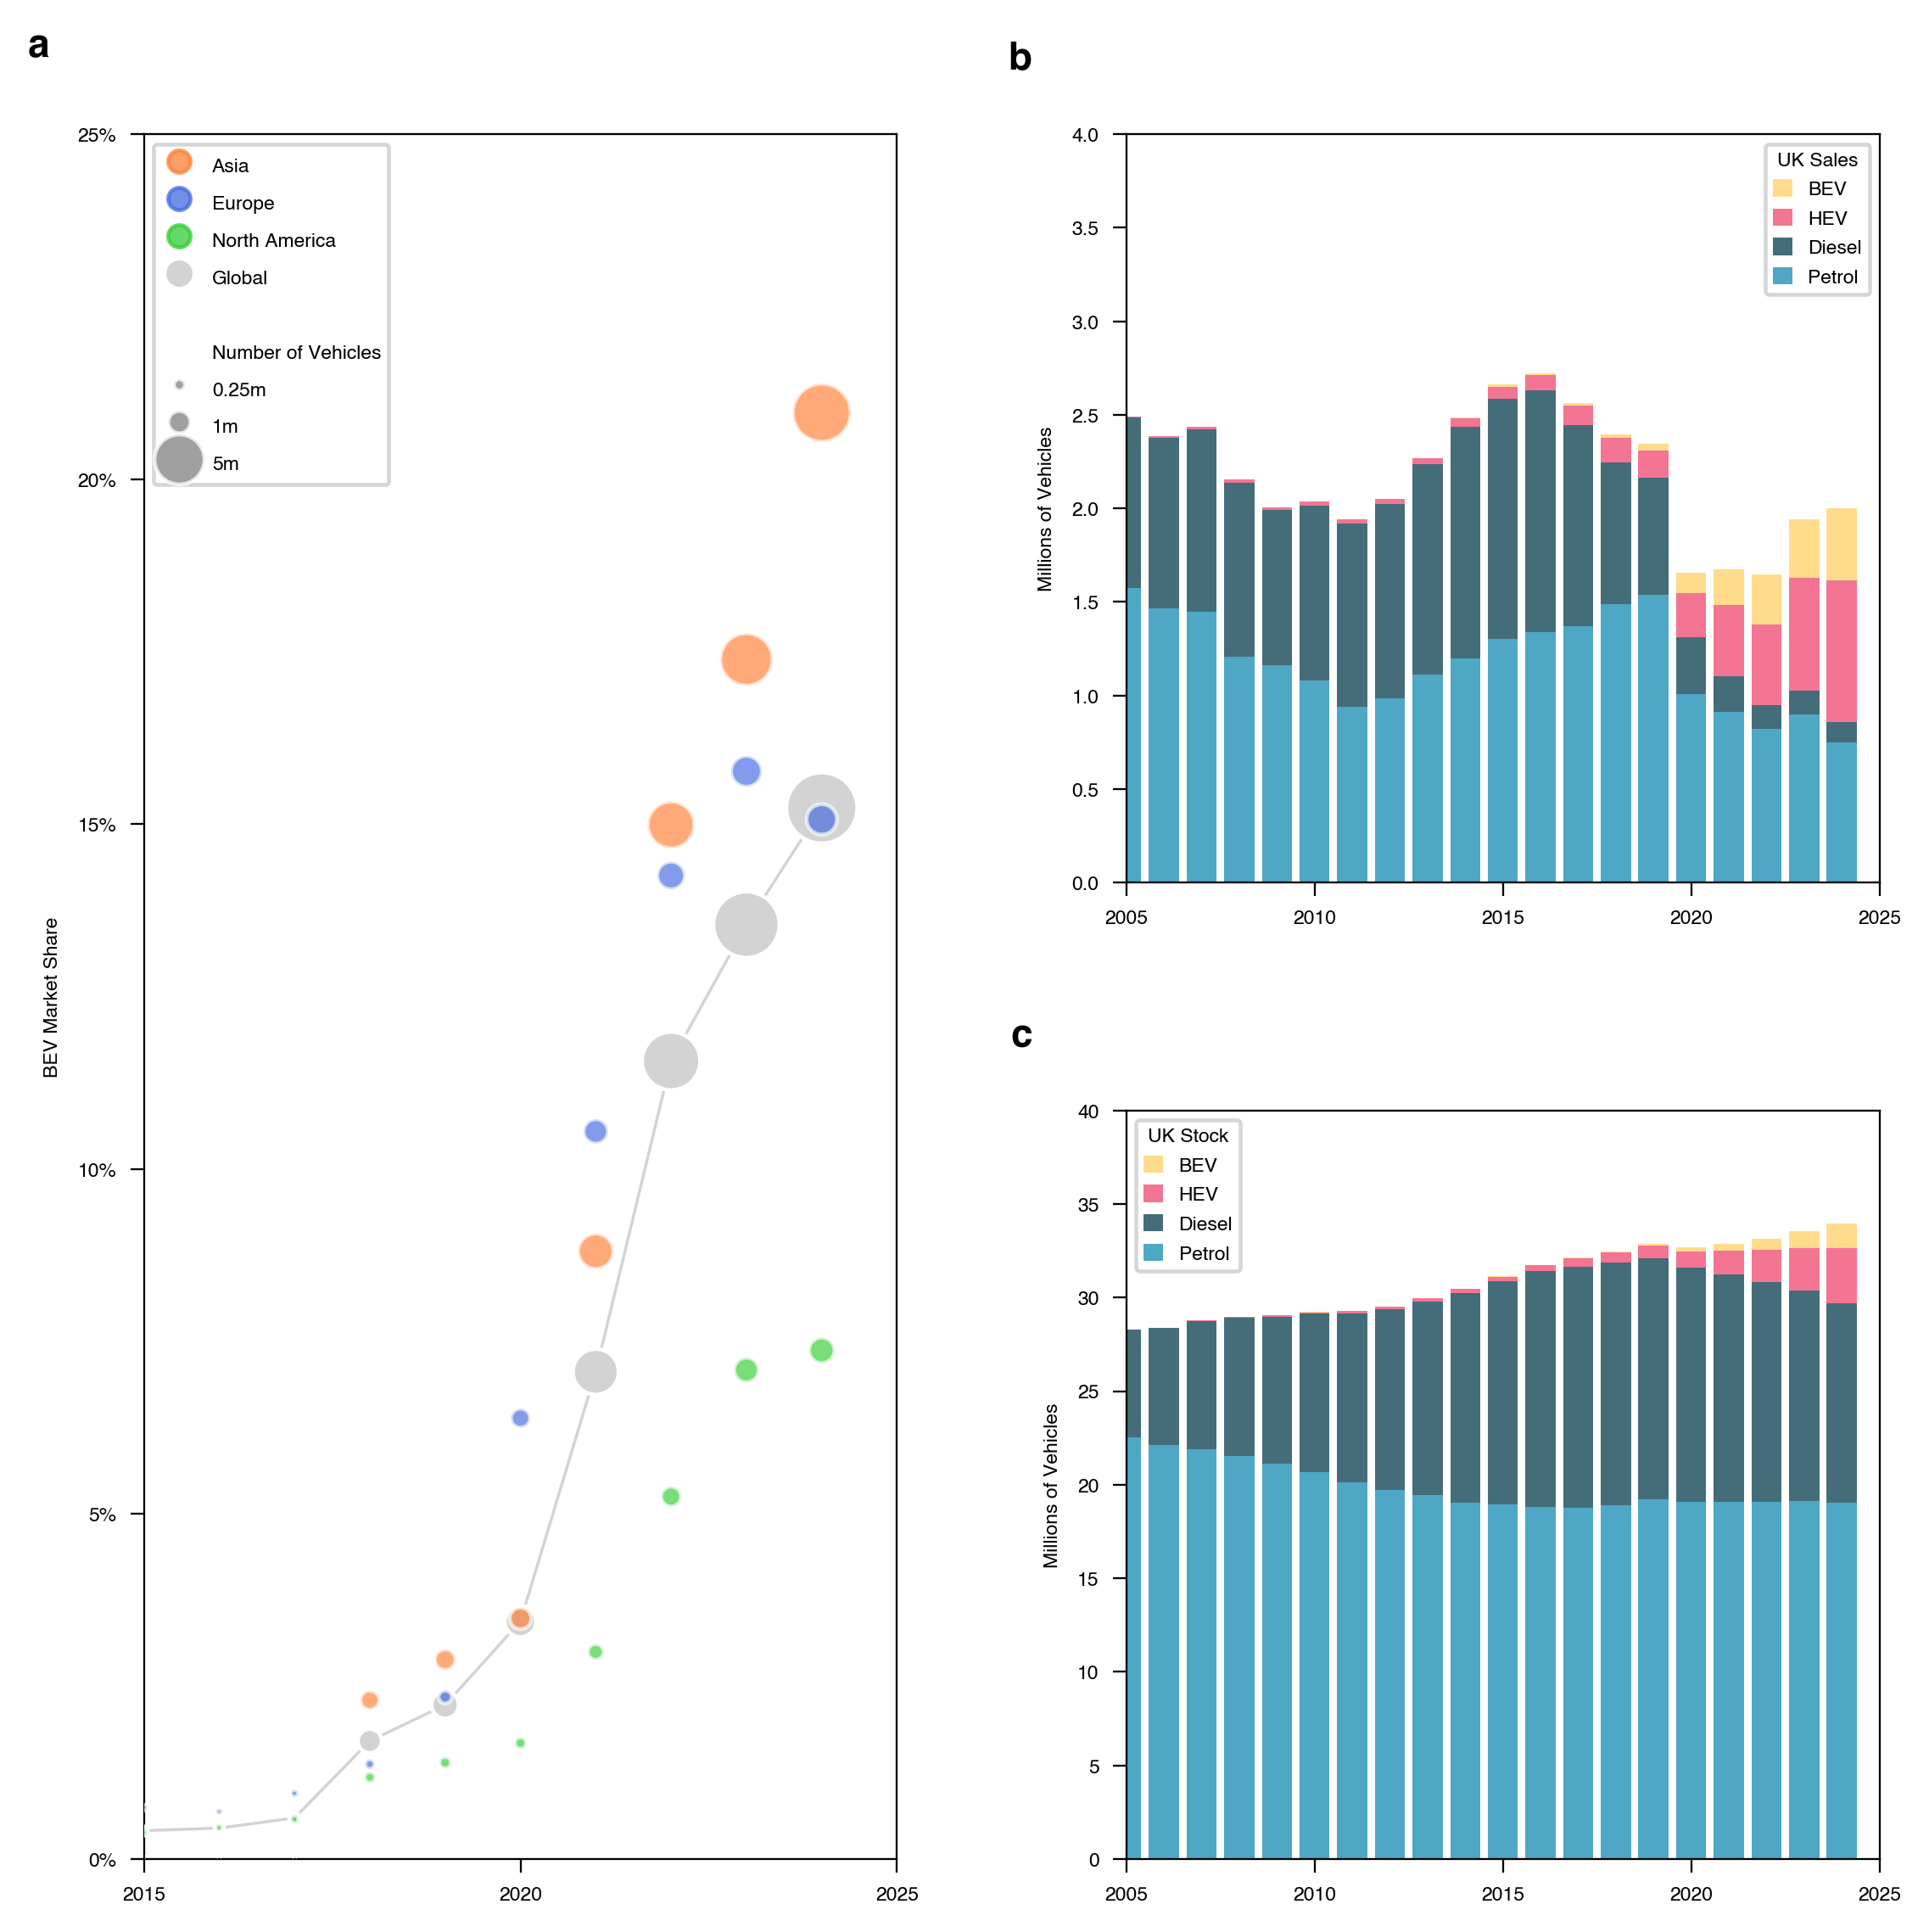

In [3]:
# Figure 1 - Sales and Stock

# Set up figure and axes - 1 rows of 4 figures
fig = plt.figure(figsize=(8,8), dpi=330)
gs = fig.add_gridspec(9, 9)
ax_a = fig.add_subplot(gs[0:9, 0:4])
ax_b = fig.add_subplot(gs[0:4, 5:9])
ax_c = fig.add_subplot(gs[5:9, 5:9])
# ax_d = fig.add_subplot(gs[0:9, 14:18])

df_bev_sales = pd.read_csv(os.path.join("data", "vehicle_sales_and_stock", "andrew_2025_all_carsales_monthly.csv"))
df_sales= pd.read_csv(os.path.join("data", "vehicle_sales_and_stock", "UK_sales_2005_2024.csv"))
df_stock = pd.read_csv(os.path.join("data", "vehicle_sales_and_stock", "UK_stock_2005_2024.csv"))

print("Plot a")

# drop United Kingdom SMMT
df_bev_sales = df_bev_sales.loc[df_bev_sales["Country"]!="United Kingdom"]
# rename United Kingdom SMMT to United Kingdom
df_bev_sales["Country"] = df_bev_sales["Country"].apply(lambda x: "United Kingdom" if x=="United Kingdom SMMT" else x)

# Editr the data first -strftime the date YYYYMM
df_bev_sales["Date"] = pd.to_datetime(df_bev_sales["YYYYMM"], format="%Y%m")
df_bev_sales["Year"] = df_bev_sales["Date"].dt.year

# convert to million units
df_bev_sales["Value"] = df_bev_sales["Value"] / 1000000 

# group by year and sum the sales
df_bev_sales = df_bev_sales.groupby(["Year", "Country", "Fuel"]).sum(numeric_only=True).reset_index()

continent_colors = {
    "Europe": "#4169E1",    # Royal Blue
    "Asia": "#FF7F33",      # Coral
    "North America": "#32CD32",  # Lime Green
    # "South America": "#FFD700",  # Gold
    # "Oceania": "#9370DB"    # Medium Purple
}

country_continents = {
    "Australia": "Oceania",
    "Austria": "Europe",
    "Brazil": "South America",
    "Canada": "North America",
    "China": "Asia",
    "Colombia": "South America",
    "Czechia": "Europe",
    "Denmark": "Europe",
    "Finland": "Europe",
    "France": "Europe",
    "Germany": "Europe",
    "Iceland": "Europe",
    "India": "Asia",
    "Indonesia": "Asia",
    "Ireland": "Europe",
    "Israel": "Asia",
    "Italy": "Europe",
    "Japan": "Asia",
    "Luxembourg": "Europe",
    "Malaysia": "Asia",
    "Mexico": "North America",
    "Netherlands": "Europe",
    "New Zealand": "Oceania",
    "Norway": "Europe",
    "Poland": "Europe",
    "Portugal": "Europe",
    "Singapore": "Asia",
    "Spain": "Europe",
    "Sweden": "Europe",
    "Switzerland": "Europe",
    "Thailand": "Asia",
    "Turkey": "Asia",
    "USA": "North America",
    "United Kingdom": "Europe",
    "Uruguay": "South America"
}

# aggregate the data based upon the continets
df_bev_sales["Continent"] = df_bev_sales["Country"].apply(lambda x: country_continents[x])
df_bev_sales_cont = df_bev_sales.groupby(["Year", "Fuel", "Continent"]).sum(numeric_only=True).reset_index()
df_bev_sales_uk = df_bev_sales.loc[df_bev_sales["Country"]=="United Kingdom"].copy()
df_bev_sales_global = df_bev_sales.groupby(["Year", "Fuel"]).sum(numeric_only=True).reset_index()

# Now create percentages of the total sales for each year 
# groupby the year and country, then divide by the sum of the sales for that year
df_bev_sales_cont["Percentage"] = df_bev_sales_cont.groupby(["Year", "Continent"])["Value"].transform(lambda x: x / x.sum())
df_bev_sales_uk["Percentage"] = df_bev_sales_uk.groupby(["Year"])["Value"].transform(lambda x: x / x.sum())
df_bev_sales_global["Percentage"] = df_bev_sales_global.groupby(["Year"])["Value"].transform(lambda x: x / x.sum())

# Keep only years between 2005 and 2023
df_bev_sales_cont = df_bev_sales_cont.loc[(df_bev_sales_cont["Year"] >= 2005) & (df_bev_sales_cont["Year"] <= 2024)]
df_bev_sales_uk = df_bev_sales_uk.loc[(df_bev_sales_uk["Year"] >= 2005) & (df_bev_sales_uk["Year"] <= 2024)]
df_bev_sales_global = df_bev_sales_global.loc[(df_bev_sales_global["Year"] >= 2005) & (df_bev_sales_global["Year"] <= 2024)]

# Only keep BEVs
df_bev_sales_cont = df_bev_sales_cont.loc[df_bev_sales_cont["Fuel"]=="BatteryElectric"]
df_bev_sales_uk = df_bev_sales_uk.loc[df_bev_sales_uk["Fuel"]=="BatteryElectric"]
df_bev_sales_global = df_bev_sales_global.loc[df_bev_sales_global["Fuel"]=="BatteryElectric"]

for continent in continent_colors.keys():
    df_continent = df_bev_sales_cont.loc[df_bev_sales_cont["Continent"]==continent]
    ax_a.scatter(df_continent["Year"], df_continent["Percentage"], s=df_continent["Value"]*33, alpha=0.66, color=continent_colors[continent], zorder=4, edgecolors="#ffffff00")

# # # plot UK separately
# ax_a.scatter(df_bev_sales_uk["Year"], df_bev_sales_uk["Percentage"],s=df_bev_sales_uk["Value"]*33, color="black", alpha=0.75, zorder=6)

# # plot global
ax_a.scatter(df_bev_sales_global["Year"], df_bev_sales_global["Percentage"], s=df_bev_sales_global["Value"]*33, color="lightgrey", zorder=3, alpha=1, edgecolors="#ffffff00")
ax_a.plot(df_bev_sales_global["Year"], df_bev_sales_global["Percentage"], color="lightgrey", alpha=1, zorder=1)

# Now create a fake legend to match the colors and scatter size 
# Contient colours
continent_colors = {
    "Asia": "#FF7F33",      
    # "Oceania": "#9370DB",   
    "Europe": "#4169E1", 
    "North America": "#32CD32",
    # "South America": "#FFD700", 
}
# ax_a.scatter([], [], color="white", label="Continent", s=33, alpha=0.75)
for continent in continent_colors.keys():
    ax_a.scatter([], [], color=continent_colors[continent], label=continent, s=33, alpha=0.75)
# ax_a.scatter([], [], color="white", label=" ", s=33, alpha=0.75)
ax_a.scatter([], [], color='lightgrey', label="Global", s=33, alpha=1)
ax_a.scatter([], [], color="white", label=" ", s=33, alpha=0.75)
# Add vehicle sales sizes for scatter s
ax_a.scatter([], [], color="white", label="Number of Vehicles", s=33, alpha=0.75)
sizes = [0.25, 1, 5]
for size in sizes:
    ax_a.scatter([], [], color="grey", label=f"{size}m", s=size*33, alpha=0.75, edgecolors="#ffffff00")
    # ax_a.scatter([], [], color="#ffffff00", label=" ", s=33, alpha=0.75)

# ax_a.scatter([], [], color='black', label="United Kingdom", s=33, alpha=0.75)

# set ylim to percentage 
ax_a.set_ylim(0, 0.25)
ax_a.set_yticks(np.arange(0, 0.26, 0.05))
ax_a.set_yticklabels(["0%", "5%", "10%", "15%", "20%", "25%"])
ax_a.legend(handleheight=1.8, handlelength=1.8, fontsize=5, loc='upper left')
ax_a.set_xlim(2015, 2025)
ax_a.set_xticks(range(2015, 2026, 5))
ax_a.set_ylabel("BEV Market Share")


print("Plot b")
colors = ["#ffd166", "#ef476f", "#118ab2", "#073b4c"] 
fuels = ["BEV", "HEV", "Diesel", "Petrol"]

stack_order = ['Petrol', 'Diesel', 'HEV', 'BEV', ]

# Create dictionary mapping fuel types to their data

# Stacked bar shart of sales 2005 to 2023 in df_sales
years = df_sales["year"]
bev_sales = df_sales["BEV"]/1000
hev_sales = df_sales["HEV"]/1000
petrol_sales = df_sales["Petrol"]/1000
diesel_sales = df_sales["Diesel"]/1000

data = {
    'BEV': bev_sales,
    'HEV': hev_sales,
    'Petrol': petrol_sales,
    'Diesel': diesel_sales,
}

# Create dictionary mapping fuel types to their colors
color_map = dict(zip(['BEV', 'HEV', 'Petrol', 'Diesel'], colors))

# Plot stacked bars
bottom = [0] * len(years) 
for fuel in stack_order:
    ax_b.bar(years, data[fuel], 
             color=color_map[fuel], 
             label=fuel, 
             bottom=bottom, 
             alpha=0.75)
    bottom += data[fuel]
  
ax_b.set_ylim(0, 4)

# reverse handle order of legend
handles, labels = ax_b.get_legend_handles_labels()
ax_b.legend( reversed(handles), reversed(labels), title="UK Sales", handleheight=1, handlelength=1, fontsize=5)
ax_b.set_ylabel("Millions of Vehicles")

print("Plot c")
colors = ["#ffd166", "#ef476f", "#118ab2", "#073b4c"] 
fuels = ["BEV", "HEV", "Diesel", "Petrol"]
# Stacked bar shart of sales 2005 to 2023 in df_sales
years = df_stock["year"]
bev_stock= df_stock["BEV"]/1000
hev_stock= df_stock["HEV"]/1000
petrol_stock= df_stock["Petrol"]/1000
diesel_stock= df_stock["Diesel"]/1000

data = {
    'BEV': bev_stock,
    'HEV': hev_stock,
    'Petrol': petrol_stock,
    'Diesel': diesel_stock,
}

# Create dictionary mapping fuel types to their colors
color_map = dict(zip(['BEV', 'HEV', 'Petrol', 'Diesel'], colors))

# Plot stacked bars
bottom = [0] * len(years) 
for fuel in stack_order:
    ax_c.bar(years, data[fuel], 
             color=color_map[fuel], 
             label=fuel, 
             bottom=bottom, 
             alpha=0.75)
    bottom += data[fuel]

ax_c.set_ylim(0, 40)
handles, labels = ax_b.get_legend_handles_labels()
ax_c.legend(reversed(handles), reversed(labels), title="UK Stock", handleheight=1, handlelength=1, fontsize=5)
ax_c.set_ylabel("Millions of Vehicles")

for ax in [ax_b, ax_c]:
    ax.set_xlim(2005, 2025)
    ax.set_xticks(range(2005, 2026, 5))

# label the axes
for ax, label in zip([ax_a], [ "a"]):
    ax.text(-0.125, 1.062, label, transform=ax.transAxes, fontsize=10, fontweight='bold', va='top', ha='right')
for ax, label in zip([ax_b, ax_c], [ "b", "c"]):
    ax.text(-0.125, 1.125, label, transform=ax.transAxes, fontsize=10, fontweight='bold', va='top', ha='right')
    
plt.savefig(os.path.join("results", "figure_1.pdf"), dpi=330)

Plot a
Plot b
Plot c
Plot d


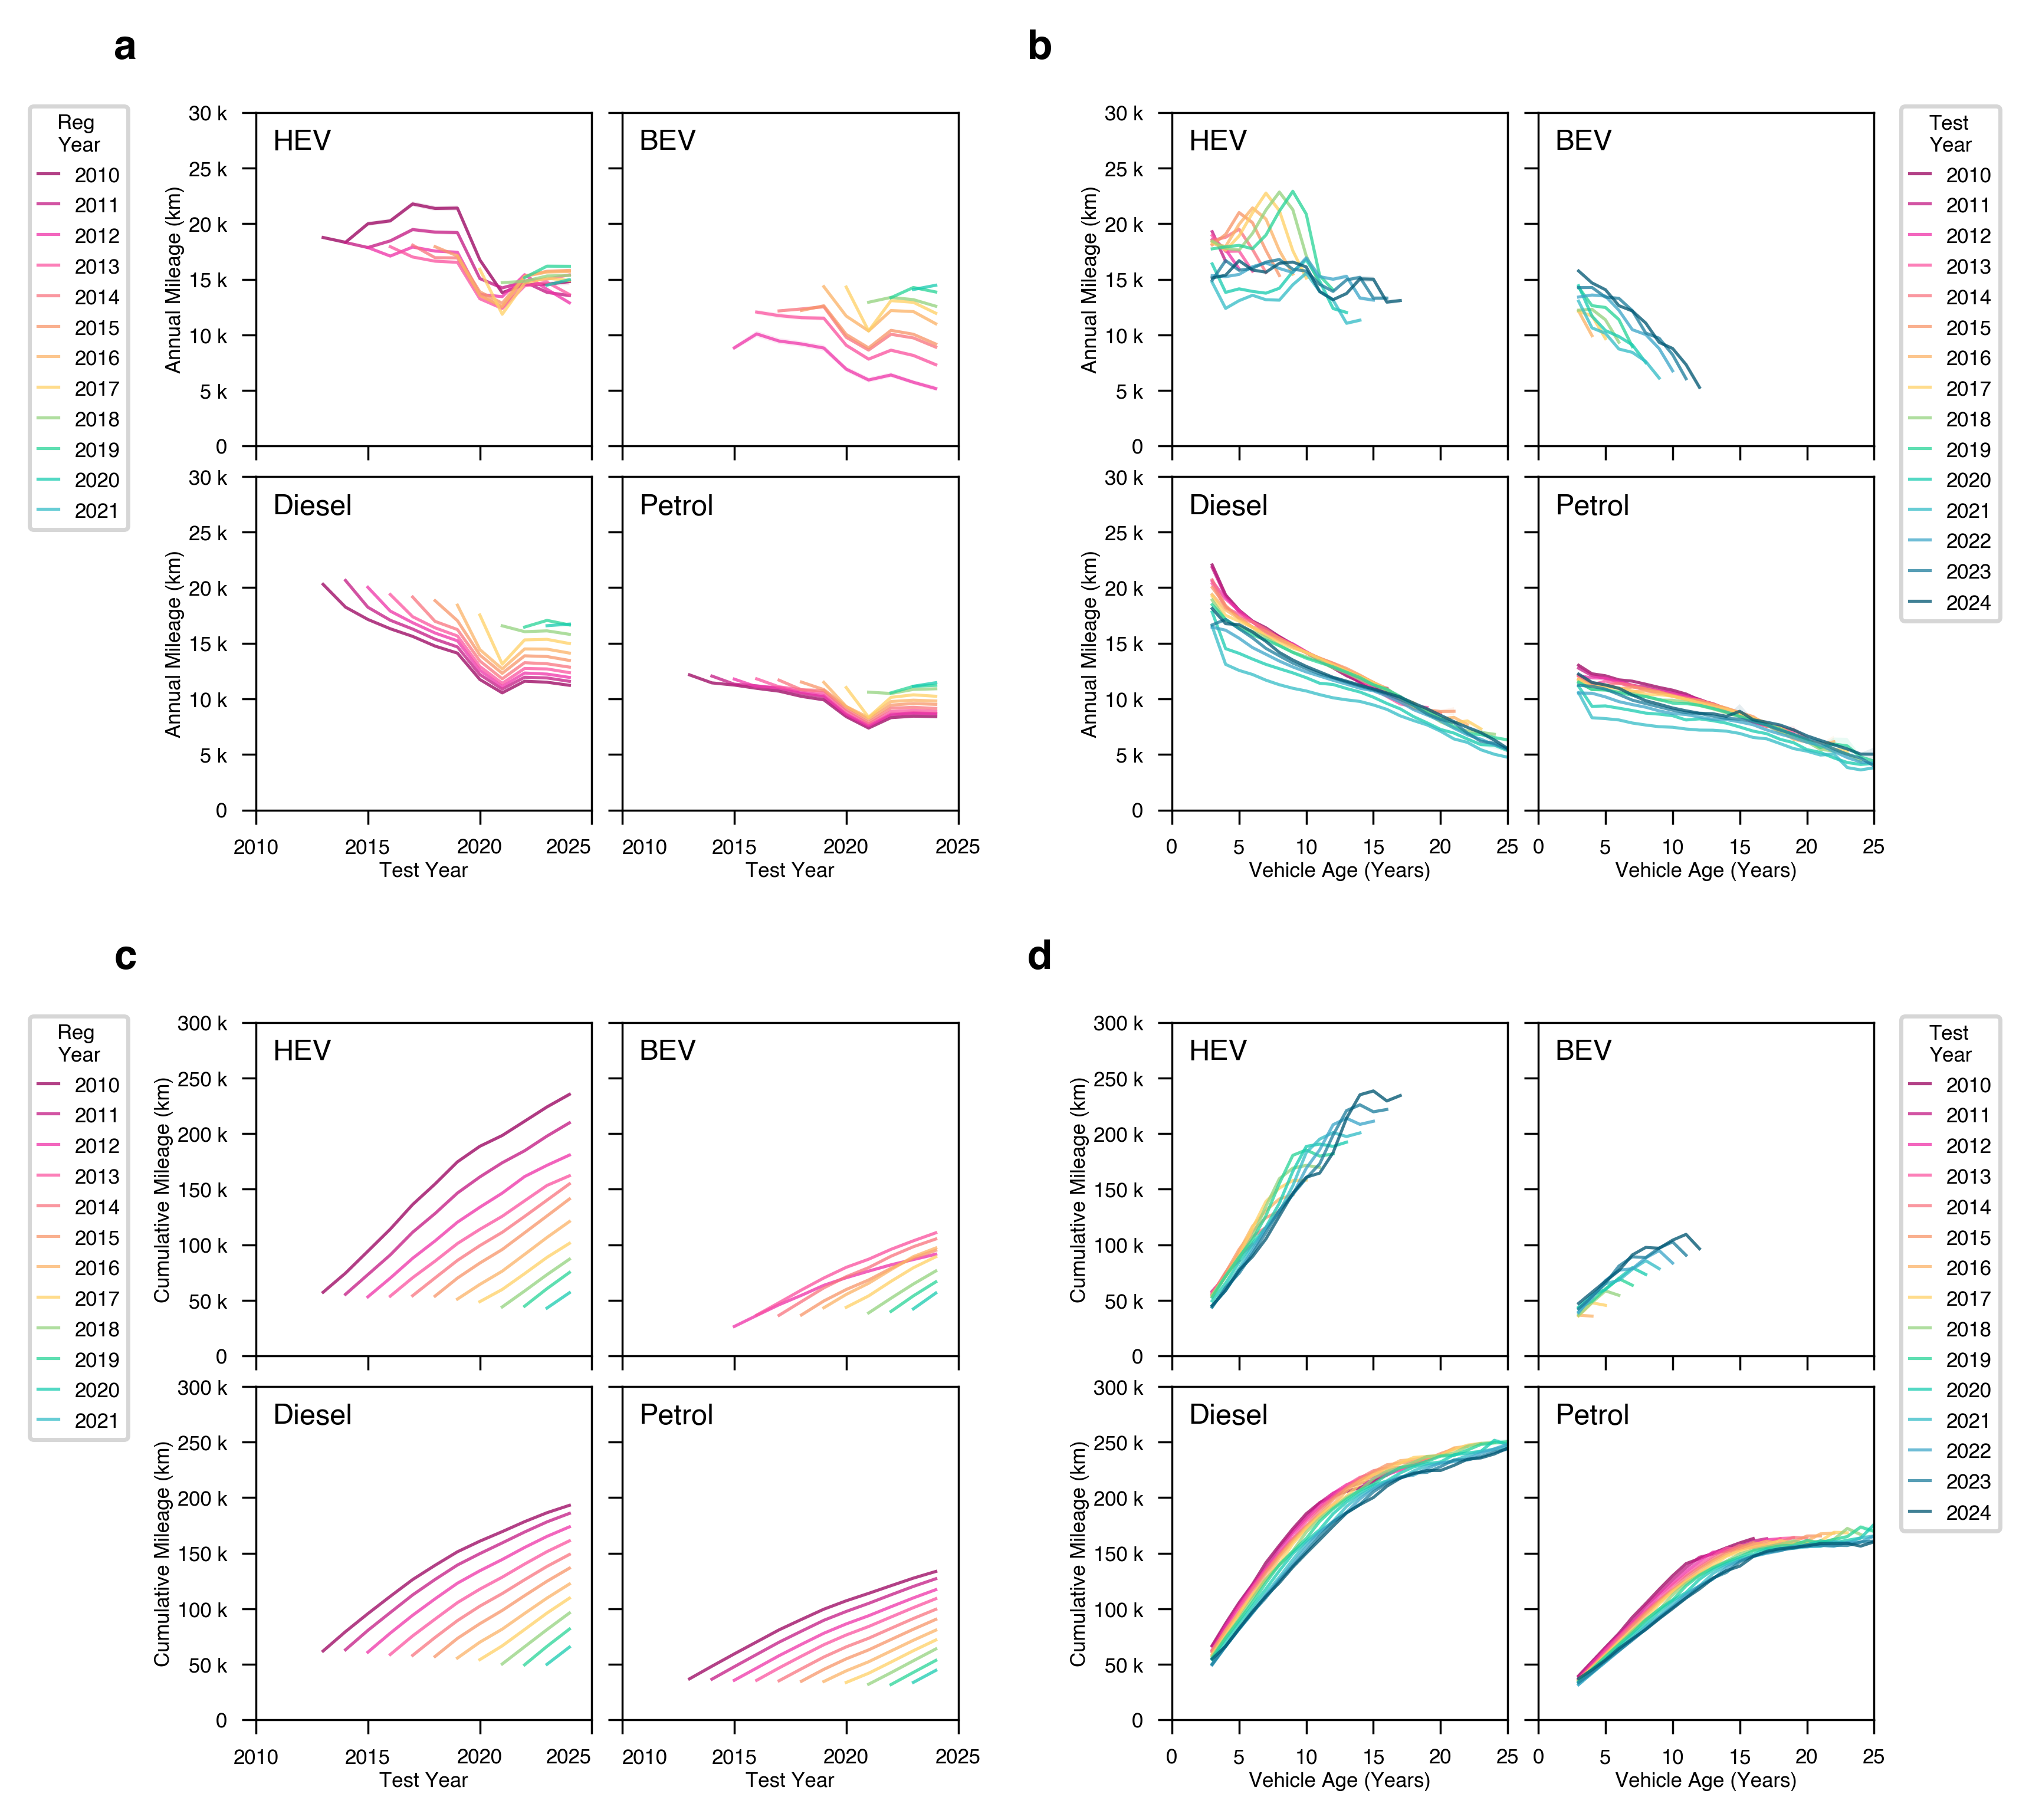

In [4]:
# Figure 2 - Mileage 

# Colours, fuels, and MOT years to iterate over and use for plotting
full_years = list(range(2010, 2025, 1))
base_colors = ["#9A015F","#FD3DB5", "#F78C6B", "#FFD166", "#06D6A0", "#48B3D7", "#005672"]
n = len(full_years)
colors = create_colormap(base_colors, n)
all_colors_lookup = {year : color for year, color in zip(full_years, colors)}

mot_years = list(range(2010, 2025, 1))
reg_years = list(range(2010, 2022, 1))

# Set up figure and axes - 2 rows of 4 figures
fig = plt.figure(figsize=(7.08, 7.08), dpi=500) # 180mm x 180mm 
gs = fig.add_gridspec(9, 9)
# First Row - Annual Mileage
# Fig A
ax1_a= fig.add_subplot(gs[0:2, 0:2])
ax2_a= fig.add_subplot(gs[0:2, 2:4])
ax3_a= fig.add_subplot(gs[2:4, 0:2])
ax4_a= fig.add_subplot(gs[2:4, 2:4])
a_axes = [ax1_a, ax2_a, ax3_a, ax4_a]
# Fig B
ax1_b = fig.add_subplot(gs[0:2, 5:7])
ax2_b = fig.add_subplot(gs[0:2, 7:9])
ax3_b = fig.add_subplot(gs[2:4, 5:7])
ax4_b = fig.add_subplot(gs[2:4, 7:9])
b_axes = [ax1_b, ax2_b, ax3_b, ax4_b]

# Second Row - Cumulative Mileage
# Fig C
ax1_c = fig.add_subplot(gs[5:7, 0:2])
ax2_c = fig.add_subplot(gs[5:7, 2:4])
ax3_c = fig.add_subplot(gs[7:9, 0:2])
ax4_c = fig.add_subplot(gs[7:9, 2:4])
c_axes = [ax1_c, ax2_c, ax3_c, ax4_c]
# Fig D
ax1_d = fig.add_subplot(gs[5:7, 5:7])
ax2_d = fig.add_subplot(gs[5:7, 7:9])
ax3_d = fig.add_subplot(gs[7:9, 5:7])
ax4_d = fig.add_subplot(gs[7:9, 7:9])
d_axes = [ax1_d, ax2_d, ax3_d, ax4_d]


print("Plot a")
data_out = []
for fuel, ax in zip(["car_hev", "car_bev", "car_diesel", "car_petrol"], a_axes):
    
    df = fuel_data[fuel]  

    
    for reg_year in reg_years: 
        
        if reg_year < get_fuel_cut_off_year(fuel):
            continue
        
        color = all_colors_lookup[reg_year]
        df_reg_year = df[df['first_use_year'] == reg_year]
        
        x_age = []
        y_mean = []
        y_std_error = []
        n = []
        
        start_year = reg_year + 3
        for year in range(start_year, 2025, 1):
            
            age = year - reg_year
            df_age = df_reg_year[df_reg_year['age_year_rounded'] == age]
            
            # now drop duplicates on vehicle ID - so no double counting / one vehicle contributing multiple times for the same year
            df_age = df_age.drop_duplicates(subset='vehicle_id', keep="last")
            
            x_age.append(year)
            y_mean.append(df_age['mileage_per_year'].mean())
            y_std_error.append(df_age['mileage_per_year'].std() / np.sqrt(len(df_age)))
            n.append(len(df_age))
                    
        y_lower = [y_mean[i] - y_std_error[i] for i in range(len(y_mean))]
        y_upper = [y_mean[i] + y_std_error[i] for i in range(len(y_mean))]
        
        ax.plot(x_age, y_mean, color=color, label=str(reg_year), linewidth=0.75, alpha=0.75)
        ax.fill_between(x_age, y_lower, y_upper, color=color, alpha=0.1, edgecolor=None)
        
        for i in range(len(x_age)):
            data_out.append([fuel, reg_year, x_age[i], y_mean[i], y_lower[i], y_upper[i], n[i]])
        
    ax.set_ylim(0, 30_000)
    ax.set_xlim(2010, 2025) 
    ax.set_xticks([2010,2015,2020,2025])
    ax.yaxis.set_major_formatter(FuncFormatter(y_fmt))
    if fuel in ["car_diesel", "car_hev"]:
        ax.set_ylabel("Annual Mileage (km)", labelpad=1)
    else:
        ax.set_yticklabels([])
    if fuel in ["car_petrol", "car_diesel"]:
        ax.set_xlabel("Test Year", labelpad=1)
    else:
        ax.set_xticklabels([])   
    ax.text(0.05, 0.95, f"{get_fuel_labels(fuel)}", transform=ax.transAxes, fontsize=7, verticalalignment='top', horizontalalignment='left')

ax1_a.legend(title="Reg\nYear",
            title_fontsize=5,
            loc="upper right", 
            fontsize=5, 
            handlelength=1, 
            handleheight=1,
            bbox_to_anchor=(-0.35, 1.05)
)

# Align the last tick label of the left plot with the first tick label of the right plot to stop overlap
# Get the tick labels
ax3_labels = ax3_a.get_xticklabels()
ax4_labels = ax4_a.get_xticklabels()
# Right-align the last tick label of the left plot
ax3_labels[-1].set_ha('right')  # ha = horizontal alignment
# Left-align the first tick label of the right plot
ax4_labels[0].set_ha('left')
# Apply the modified tick labels back to the axes
ax3_a.set_xticklabels(ax3_labels)
ax4_a.set_xticklabels(ax4_labels)

data_out = pd.DataFrame(data_out, columns=["fuel", "reg_year", "test_year", "y_mean", "y_lower", "y_upper", "n"])
data_out.to_csv(os.path.join(script_path, "results", "figure_2_plot_a.csv"))

print("Plot b")
data_out = []
for fuel, ax in zip(["car_hev", "car_bev", "car_diesel", "car_petrol"], b_axes):

    df = fuel_data[fuel]    
    
    for mot_year  in mot_years:
        
        color = all_colors_lookup[mot_year]

        mot_lower = datetime.datetime(mot_year,1,1,0,0,0,0)
        mot_upper = datetime.datetime(mot_year+1,1,1,0,0,0,0)
        df_view = df[(df['test_date'] < mot_upper ) &(df['test_date'] > mot_lower)]

        age_lim = mot_year - get_fuel_cut_off_year(fuel)

        x_age = []
        y_mean = []
        n = []
        std_e = []
        
        ages = list(range(3,age_lim+1,1))  # 0 to age_lim
        for age in ages:
            df_view_age = df_view[df_view['age_year_rounded'] == age]
            
            # now drop duplicates on vehicle ID - so no double counting
            df_view_age = df_view_age.drop_duplicates(subset='vehicle_id', keep="last")
            
            data_col = "mileage_per_year"
            y_mean.append(df_view_age[data_col].mean())
            x_age.append(age)
            n.append(len(df_view_age))  
            std_e.append(df_view_age[data_col].std() / np.sqrt(len(df_view_age)) )
            
        # Add false line to fill the legend for BEVs
        if len(x_age) == 0:
            ax.plot([], [], color=color, label=str(mot_year), linewidth=0.75, alpha=0.75)
            continue
            
        y_lower = [y_mean[i] - std_e[i] for i in range(len(y_mean))]
        y_upper = [y_mean[i] + std_e[i] for i in range(len(y_mean))]
        ax.plot(x_age, y_mean, color=color, label=str(mot_year), linewidth=0.75, alpha=0.75)
        ax.fill_between(x_age, y_lower, y_upper, color=color, alpha=0.1, edgecolor=None)
                    
        for i in range(len(x_age)):
            data_out.append([fuel, mot_year, x_age[i], y_mean[i], y_lower[i], y_upper[i], n[i]])

    ax.text(0.05, 0.95, f"{get_fuel_labels(fuel)}", transform=ax.transAxes, fontsize=7, verticalalignment='top', horizontalalignment='left')
    
    ax.set_ylim(0, 30_000)
    ax.set_xlim(0,25)
    ax.yaxis.set_major_formatter(FuncFormatter(y_fmt))
    ax.set_xticks([0,5,10,15,20,25]) 
    
    if fuel in ["car_diesel", "car_hev"]:
        ax.set_ylabel("Annual Mileage (km)", labelpad=1)
    else:
        ax.set_yticklabels([])
    if fuel in ["car_petrol", "car_diesel"]:
        ax.set_xlabel("Vehicle Age (Years)", labelpad=1)
    else:
        ax.set_xticklabels([])         
ax2_b.legend(title="Test\nYear",
            title_fontsize=5,
            loc="upper left", 
            fontsize=5, 
            handlelength=1, 
            handleheight=1,
            bbox_to_anchor=(1.05, 1.05)
)

data_out = pd.DataFrame(data_out, columns=["fuel", "test_year", "age", "y_mean", "y_lower", "y_upper", "n"])
data_out.to_csv(os.path.join(script_path, "results", "figure_2_plot_b.csv"))    

print("Plot c")
data_out = []
for fuel, ax in zip(["car_hev", "car_bev", "car_diesel", "car_petrol"], c_axes):
    
    df = fuel_data[fuel]  
    
    for reg_year in reg_years: 
        
        if reg_year < get_fuel_cut_off_year(fuel):
            continue
        
        color = all_colors_lookup[reg_year]
        df_reg_year = df[df['first_use_year'] == reg_year]
        
        x_age = []
        y_mean = []
        y_std_error = []
        n = [] 
        
        start_year = reg_year + 3
        for year in range(start_year, 2025, 1):
            
            age = year - reg_year
            df_age = df_reg_year[df_reg_year['age_year_rounded'] == age]
            # now drop duplicates on vehicle ID - so no double counting
            df_age = df_age.drop_duplicates(subset='vehicle_id', keep="last")
            x_age.append(year)
            y_mean.append(df_age['test_mileage'].mean())
            y_std_error.append(df_age['test_mileage'].std() / np.sqrt(len(df_age)))
            n.append(len(df_age))
        
        y_lower = [y_mean[i] - y_std_error[i] for i in range(len(y_mean))]
        y_upper = [y_mean[i] + y_std_error[i] for i in range(len(y_mean))]
        
        ax.plot(x_age, y_mean, color=color, label=str(reg_year), linewidth=0.75, alpha=0.75)
        ax.fill_between(x_age, y_lower, y_upper, color=color, alpha=0.1, edgecolor=None)
        for i in range(len(x_age)):
            data_out.append([fuel, reg_year, x_age[i], y_mean[i], y_lower[i], y_upper[i], n[i]])
        
    ax.set_ylim(0, 300_000)
    ax.set_xlim(2010,2025) 
    ax.set_xticks([2010,2015,2020,2025])
    ax.yaxis.set_major_formatter(FuncFormatter(y_fmt))
    if fuel in ["car_diesel", "car_hev"]:
        ax.set_ylabel("Cumulative Mileage (km)", labelpad=1)
    else:
        ax.set_yticklabels([])
    if fuel in ["car_petrol", "car_diesel"]:
        ax.set_xlabel("Test Year", labelpad=1)
    else:
        ax.set_xticklabels([])   
    ax.text(0.05, 0.95, f"{get_fuel_labels(fuel)}", transform=ax.transAxes, fontsize=7, verticalalignment='top', horizontalalignment='left')

ax1_c.legend(title="Reg\nYear",
            title_fontsize=5,
            loc="upper right", 
            fontsize=5, 
            handlelength=1, 
            handleheight=1,
            bbox_to_anchor=(-0.35, 1.05)
)

# Align the last tick label of the left plot with the first tick label of the right plot to stop overlap
# Get the tick labels
ax3_labels = ax3_c.get_xticklabels()
ax4_labels = ax4_c.get_xticklabels()
# Right-align the last tick label of the left plot
ax3_labels[-1].set_ha('right')  # ha = horizontal alignment
# Left-align the first tick label of the right plot
ax4_labels[0].set_ha('left')
# Apply the modified tick labels back to the axes
ax3_c.set_xticklabels(ax3_labels)
ax4_c.set_xticklabels(ax4_labels)

data_out = pd.DataFrame(data_out, columns=["fuel", "reg_year", "test_year", "y_mean", "y_lower", "y_upper", "n"])
data_out.to_csv(os.path.join(script_path, "results", "figure_2_plot_c.csv"))

print("Plot d")
data_out = []
for fuel, ax in zip(["car_hev", "car_bev", "car_diesel", "car_petrol"], d_axes):
    
    df = fuel_data[fuel]  
    for mot_year  in mot_years:
        color = all_colors_lookup[mot_year]
        
        # filter dataset to MOT year
        mot_lower = datetime.datetime(mot_year,1,1,0,0,0,0)
        mot_upper = datetime.datetime(mot_year+1,1,1,0,0,0,0)
        df_view = df[(df['test_date'] < mot_upper ) &(df['test_date'] > mot_lower )]

        # Get age limit
        age_lim = mot_year - get_fuel_cut_off_year(fuel)

        x_age = []
        y_mean = []
        n = []
        std_e = []
        
        ages = list(range(3, age_lim+1, 1))
        for age in ages:
            df_view_age = df_view[(df_view['age_year_rounded'] == age)]
            
            # now drop duplicates on vehicle ID - so no double counting
            df_view_age = df_view_age.drop_duplicates(subset='vehicle_id', keep="last")
            
            data_col = "test_mileage"
            y_mean.append(df_view_age[data_col].mean())
            x_age.append(age)
            n.append(len(df_view_age))
            std_e.append(df_view_age[data_col].std() / np.sqrt(len(df_view_age)) )
            
        # Add false line to fill the legend for BEVs
        if len(x_age) == 0:
            ax.plot([], [], color=color, label=str(mot_year), linewidth=0.75, alpha=0.75)
            continue
        
        y_lower = [y_mean[i] - std_e[i] for i in range(len(y_mean))]
        y_upper = [y_mean[i] + std_e[i] for i in range(len(y_mean))]
        
        ax.plot(x_age, y_mean, color=color, label=str(mot_year), linewidth=0.75, alpha=0.75)      
        ax.fill_between(x_age, y_lower, y_upper, color=color, alpha=0.1, edgecolor=None)
        
        
        for i in range(len(x_age)):
            data_out.append([fuel, mot_year, x_age[i], y_mean[i], y_lower[i], y_upper[i], n[i]])
        
    ax.text(0.05, 0.95, f"{get_fuel_labels(fuel)}", transform=ax.transAxes, fontsize=7, verticalalignment='top', horizontalalignment='left')
    ax.set_ylim(0, 300_000)
    ax.set_xlim(0, 25)
    ax.yaxis.set_major_formatter(FuncFormatter(y_fmt))
    ax.set_xticks([0,5,10,15,20,25])
    if fuel in ["car_diesel", "car_hev"]:
        ax.set_ylabel("Cumulative Mileage (km)", labelpad=1)
    else:
        ax.set_yticklabels([])
    if fuel in ["car_petrol", "car_diesel"]:
        ax.set_xlabel("Vehicle Age (Years)", labelpad=1)
    else:
        ax.set_xticklabels([])
        
ax2_d.legend(title="Test\nYear",
            title_fontsize=5,
            loc="upper left", 
            fontsize=5, 
            handlelength=1, 
            handleheight=1,
            bbox_to_anchor=(1.05, 1.05)
)


data_out = pd.DataFrame(data_out, columns=["fuel", "test_year", "age", "y_mean", "y_lower", "y_upper", "n"])
data_out.to_csv(os.path.join(script_path, "results", "figure_2_plot_d.csv"))

# Now add A, B, C, D, 
for ax, c, in zip(
    [ax1_a, ax1_b, ax1_c, ax1_d],
    ["a", "b", "c", "d"]
    ):
    
    if c in ["a", "b", "c", "d"]:
        ax.text(-0.355, 1.25, c, transform=ax.transAxes,fontsize=10, fontweight='bold', va='top', ha='right')
    else: 
        ax.text(-0.125, 1.125, c, transform=ax.transAxes, fontsize=10, fontweight='bold', va='top', ha='right')

plt.savefig(os.path.join(script_path, "results", "figure_2.pdf"), dpi=500, format='pdf')

Plot a
Plot c
Plot b
Plot d


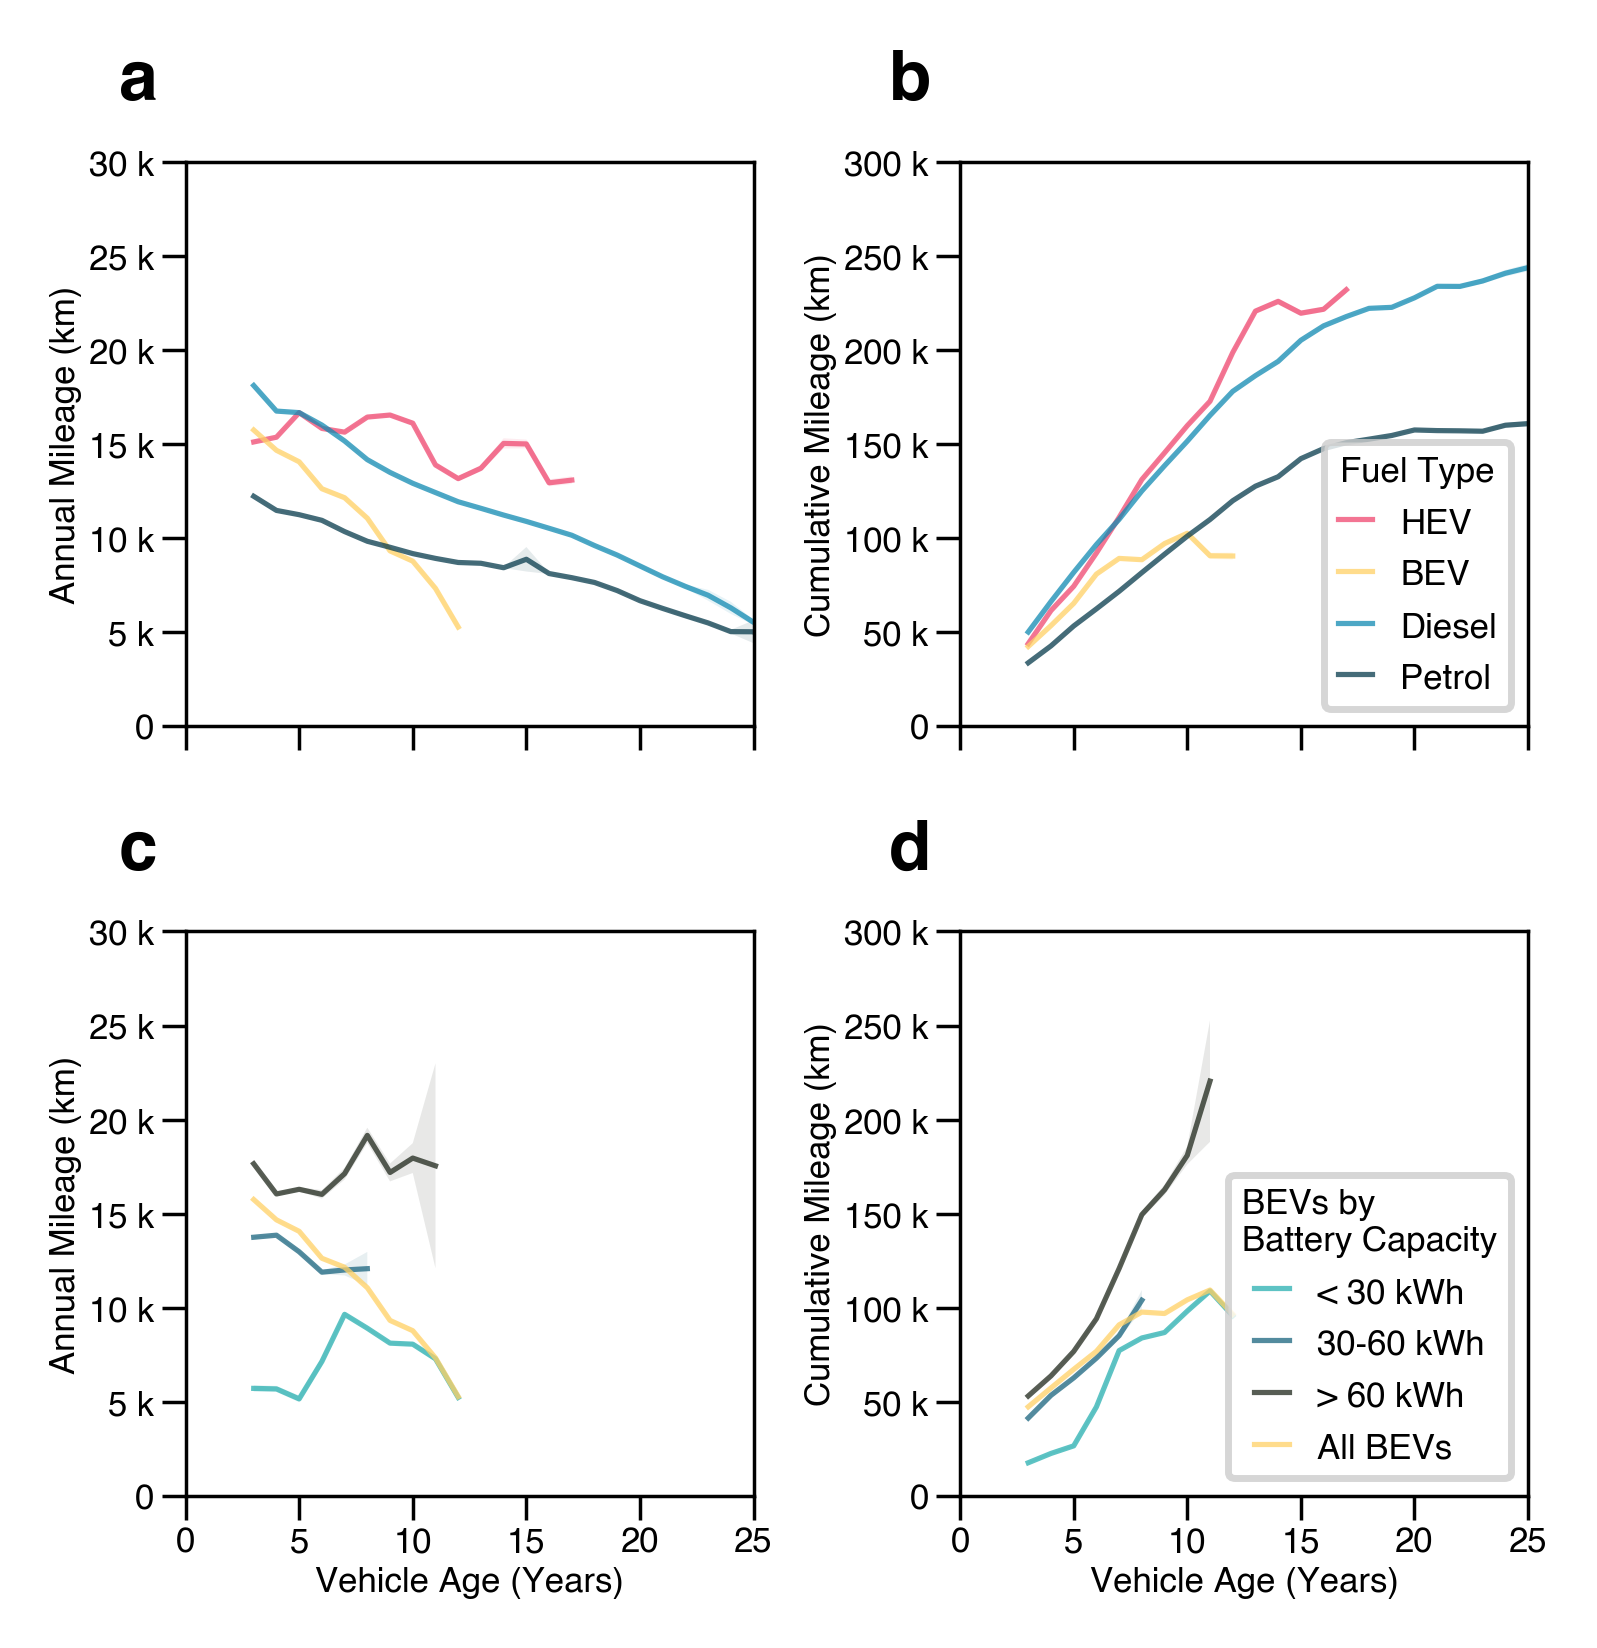

In [5]:
# Figure 3 - Mileage by fuel type and BEV Battery Capacity

fuels = ["car_hev", "car_bev", "car_diesel", "car_petrol"]
fuel_colours = ["#ef476f", "#ffd166","#118ab2", "#073b4c"]
fuel_colors_lookup = {fuel : color for fuel, color in zip(fuels, fuel_colours)}

fuels_battery = [ "car_bev_battery_30", "car_bev_battery_60", "car_bev_battery_100", "car_bev"]
fuel_colours_battery = ["#28AFB0", "#19647E", "#1F271B", "#ffd166"]
fuel_colors_lookup_battery = {fuel : color for fuel, color in zip(fuels_battery, fuel_colours_battery)}

# Set up figure and axes - 2 x 2 grid of figures
fig = plt.figure(figsize=(3.46457, 3.46457), dpi=500) # 88mm x 88mm
gs = fig.add_gridspec(9, 9, wspace=0.5, hspace=0.5)
ax_a = fig.add_subplot(gs[0:4, 0:4]) # annual mileage by fuel type
ax_b = fig.add_subplot(gs[0:4, 5:9]) # annual mileage by battery capacity
ax_c = fig.add_subplot(gs[5:9, 0:4]) # cumulative mileage by fuel type 
ax_d = fig.add_subplot(gs[5:9, 5:9]) # cumulative mileage by battery capacity

print("Plot a")
ax = ax_a
data_out = []
for fuel in ["car_hev", "car_bev", "car_diesel", "car_petrol"]:
    color = fuel_colors_lookup[fuel]
    
    df = fuel_data[fuel]  

    mot_lower = datetime.datetime(2024,1,1,0,0,0,0)
    mot_upper = datetime.datetime(2024+1,1,1,0,0,0,0)
    df_view = df[(df['test_date'] < mot_upper ) &(df['test_date'] > mot_lower )]

    age_lim = 2024 - get_fuel_cut_off_year(fuel)

    x_age = []
    y_mean = []
    n = []
    std_e = []
    
    ages = list(range(3,age_lim+1,1))  # 0 to age_lim
    for age in ages:
        df_view_age = df_view[df_view['age_year_rounded']==age]
        
        # now drop duplicates on vehicle ID - so no double counting
        df_view_age = df_view_age.drop_duplicates(subset='vehicle_id', keep="last")
        data_col = "mileage_per_year"
        y_mean.append(df_view_age[data_col].mean())
        x_age.append(age)
        n.append(len(df_view_age))
        std_e.append(df_view_age[data_col].std() / np.sqrt(len(df_view_age)) )
        
    y_lower = [y_mean[i] - std_e[i] for i in range(len(y_mean))]
    y_upper = [y_mean[i] + std_e[i] for i in range(len(y_mean))]
    
    ax.plot(x_age, y_mean, color=color, label=f"{get_fuel_labels(fuel)}", linewidth=0.75, alpha=0.75)
    ax.fill_between(x_age, y_lower, y_upper, color=color, alpha=0.1, edgecolor=None)
    
    for i in range(len(x_age)):
        data_out.append([fuel, x_age[i], y_mean[i], y_lower[i], y_upper[i], n[i]])

    ax.set_ylim(0, 30_000)
    ax.set_xlim(0,25)
    ax.set_xticks([0,5,10,15,20,25])
    ax.set_xticklabels([])
    ax.yaxis.set_major_formatter(FuncFormatter(y_fmt))
    
    ax.set_ylabel("Annual Mileage (km)", labelpad=1)

data_out = pd.DataFrame(data_out, columns=["fuel", "age", "y_mean", "y_lower", "y_upper", "n"])
data_out.to_csv(os.path.join(script_path, "results", "figure_3_plot_a.csv"))


print("Plot c")
ax = ax_c
data_out = []
for fuel in fuels_battery:
    color = fuel_colors_lookup_battery[fuel]
    
    df = fuel_data[fuel]  
    
    mot_lower = datetime.datetime(2024,1,1,0,0,0,0)
    mot_upper = datetime.datetime(2024+1,1,1,0,0,0,0)
    df_view = df[(df['test_date'] < mot_upper ) &(df['test_date'] > mot_lower )]
    # Get age limit
    age_lim = 2024 - get_fuel_cut_off_year("car_bev")

    x_age = []
    y_mean = []
    n = []
    std_e = []
    
    ages = list(range(3,age_lim+1,1))  # 0 to age_lim
    for age in ages:
        df_view_age = df_view[(df_view['age_year_rounded'] == age)]
        
        # now drop duplicates on vehicle ID - so no double counting
        df_view_age = df_view_age.drop_duplicates(subset='vehicle_id', keep="last")
        data_col = "mileage_per_year"
        y_mean.append(df_view_age[data_col].mean())
        x_age.append(age)
        n.append(len(df_view_age))
        std_e.append(df_view_age[data_col].std() / np.sqrt(len(df_view_age)) )

    y_lower = [y_mean[i] - std_e[i] for i in range(len(y_mean))]
    y_upper = [y_mean[i] + std_e[i] for i in range(len(y_mean))]

    if fuel == "car_bev":
        ax.plot(x_age, y_mean, color=color, label=f"{get_fuel_labels(fuel)}", linewidth=0.75, alpha=0.75)
        ax.fill_between(x_age, y_lower, y_upper, color=color, alpha=0.1, edgecolor=None)
        
    else:
        ax.plot(x_age, y_mean, color=color, label=f"{get_fuel_labels_disag(fuel)}", linewidth=0.75, alpha=0.75)
        ax.fill_between(x_age, y_lower, y_upper, color=color, alpha=0.1, edgecolor=None)
    for i in range(len(x_age)):    
        data_out.append([fuel, x_age[i], y_mean[i], y_lower[i], y_upper[i], n[i]])

    ax.set_ylim(0, 30_000)
    ax.set_xlim(0, 25)
    ax.yaxis.set_major_formatter(FuncFormatter(y_fmt))
    ax.set_ylabel("Annual Mileage (km)", labelpad=1)
    ax.set_xlabel("Vehicle Age (Years)", labelpad=1)

data_out = pd.DataFrame(data_out, columns=["fuel", "age", "y_mean", "y_lower", "y_upper", "n"])
data_out.to_csv(os.path.join(script_path, "results", "figure_3_plot_c.csv"))

print("Plot b")
data_out = []
ax = ax_b
for fuel in ["car_hev", "car_bev", "car_diesel", "car_petrol"]:
    color = fuel_colors_lookup[fuel]
    
    df = fuel_data[fuel]  

    # filter dataset to MOT year
    mot_lower = datetime.datetime(2023,1,1,0,0,0,0)
    mot_upper = datetime.datetime(2023+1,1,1,0,0,0,0)
    df_view = df[(df['test_date'] < mot_upper ) &(df['test_date'] > mot_lower)]

    # Get age limit
    age_lim = 2024 - get_fuel_cut_off_year(fuel)

    x_age = []
    y_mean = []
    n = []
    std_e = []
    
    ages = list(range(3,age_lim+1,1))  # 0 to age_lim
    for age in ages:
        upper = age + 0.5
        lower = age - 0.5
        df_view_age = df_view[(df_view['age_year_rounded'] == age)]
        
        # now drop duplicates on vehicle ID - so no double counting
        df_view_age = df_view_age.drop_duplicates(subset='vehicle_id', keep="last")
        data_col = "test_mileage"
        y_mean.append(df_view_age[data_col].mean())
        x_age.append(age)
        n.append(len(df_view_age))
        std_e.append(df_view_age[data_col].std() / np.sqrt(len(df_view_age)) )

    y_lower = [y_mean[i] - std_e[i] for i in range(len(y_mean))]
    y_upper = [y_mean[i] + std_e[i] for i in range(len(y_mean))]
    if fuel == "car_bev":
        label = f"{get_fuel_labels(fuel)}"
    else:
        label = f"{get_fuel_labels_disag(fuel)}"
    ax.plot(x_age, y_mean, color=color, label=label, linewidth=0.75, alpha=0.75)
    ax.fill_between(x_age, y_lower, y_upper, color=color, alpha=0.1, edgecolor=None)
    for i in range(len(x_age)):
        data_out.append([fuel, x_age[i], y_mean[i], y_lower[i], y_upper[i], n[i]])
    ax.set_ylim(0, 300_000)
    ax.set_xlim(0,25)
    ax.set_xticks([0,5,10,15,20,25])
    ax.set_xticklabels([])
    ax.yaxis.set_major_formatter(FuncFormatter(y_fmt))
    ax.set_ylabel("Cumulative Mileage (km)", labelpad=1)

ax.legend(
    title="Fuel Type",
    title_fontsize=5,
    fontsize=5, 
    loc="lower right", 
    handlelength=1, 
    handleheight=1,
    )

data_out = pd.DataFrame(data_out, columns=["fuel", "age", "y_mean", "y_lower", "y_upper", "n"])
data_out.to_csv(os.path.join(script_path, "results", "figure_3_plot_b.csv"))

print("Plot d")
ax = ax_d
data_out = []
for fuel in fuels_battery:
    
    color = fuel_colors_lookup_battery[fuel]
    
    df = fuel_data[fuel] 

    mot_lower = datetime.datetime(2024,1,1,0,0,0,0)
    mot_upper = datetime.datetime(2024+1,1,1,0,0,0,0)
    df_view = df[(df['test_date'] < mot_upper ) &(df['test_date'] > mot_lower)]

    # Get age limit
    age_lim = 2024 - get_fuel_cut_off_year("car_bev")

    x_age = []
    y_mean = []
    n = []
    std_e = []
    
    ages = list(range(3,age_lim+1,1))  # 0 to age_lim
    for age in ages:
        df_view_age = df_view[df_view['age_year_rounded']==age]
        
        # now drop duplicates on vehicle ID - so no double counting
        df_view_age = df_view_age.drop_duplicates(subset='vehicle_id', keep="last")
        data_col = "test_mileage"
        y_mean.append(df_view_age[data_col].mean())
        x_age.append(age)
        n.append(len(df_view_age))
        std_e.append(df_view_age[data_col].std() / np.sqrt(len(df_view_age)))
    
    y_lower = [y_mean[i] - std_e[i] for i in range(len(y_mean))]
    y_upper = [y_mean[i] + std_e[i] for i in range(len(y_mean))]
    
    if fuel == "car_bev":
        ax.plot(x_age, y_mean, color=color, label=f"{get_fuel_labels_disag(fuel)}", linewidth=0.75, alpha=0.75)
        ax.fill_between(x_age, y_lower, y_upper, color=color, alpha=0.1, edgecolor=None)
    else:
        ax.plot(x_age, y_mean, color=color, label=f"{get_fuel_labels_disag(fuel)}", linewidth=0.75, alpha=0.75)
        ax.fill_between(x_age, y_lower, y_upper, color=color, alpha=0.1, edgecolor=None)
    for i in range(len(x_age)):
        data_out.append([fuel, x_age[i], y_mean[i], y_lower[i], y_upper[i], n[i]])
    
    y_lower = 0 
    y_upper = 300_000 
    ax.set_ylim(y_lower, y_upper)
    ax.set_xlim(0,25)
    ax.yaxis.set_major_formatter(FuncFormatter(y_fmt))
    ax.set_ylabel("Cumulative Mileage (km)", labelpad=1)
    ax.set_xlabel("Vehicle Age (Years)", labelpad=1)

ax.legend(
    loc="lower right", 
    fontsize=5, 
    handleheight=1, 
    handlelength=1, 
    title="BEVs by\nBattery Capacity",
)

data_out = pd.DataFrame(data_out, columns=["fuel", "age", "y_mean", "y_lower", "y_upper", "n"])
data_out.to_csv(os.path.join(script_path, "results", "figure_3_plot_d.csv"))

# Now add A, B, C, D
for ax, c, in zip(
    [ax_a, ax_b, ax_c, ax_d],
    ["a", "b", "c", "d"]
    ):
    
    ax.text(-0.05, 1.2, c, transform=ax.transAxes,fontsize=10, fontweight='bold', va='top', ha='right')
    
    # adjust label spacing 
    ax.tick_params(axis='both', pad=1)  
                   
plt.savefig(os.path.join(script_path, "results", "figure_3.pdf"), dpi=500, format='pdf')

Plot a
Plot b
Plot c
Plot d


c:\Users\mehlig\miniconda3\envs\ML\Lib\site-packages\scipy\interpolate\_interpolate.py:712: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
c:\Users\mehlig\miniconda3\envs\ML\Lib\site-packages\scipy\interpolate\_interpolate.py:712: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]


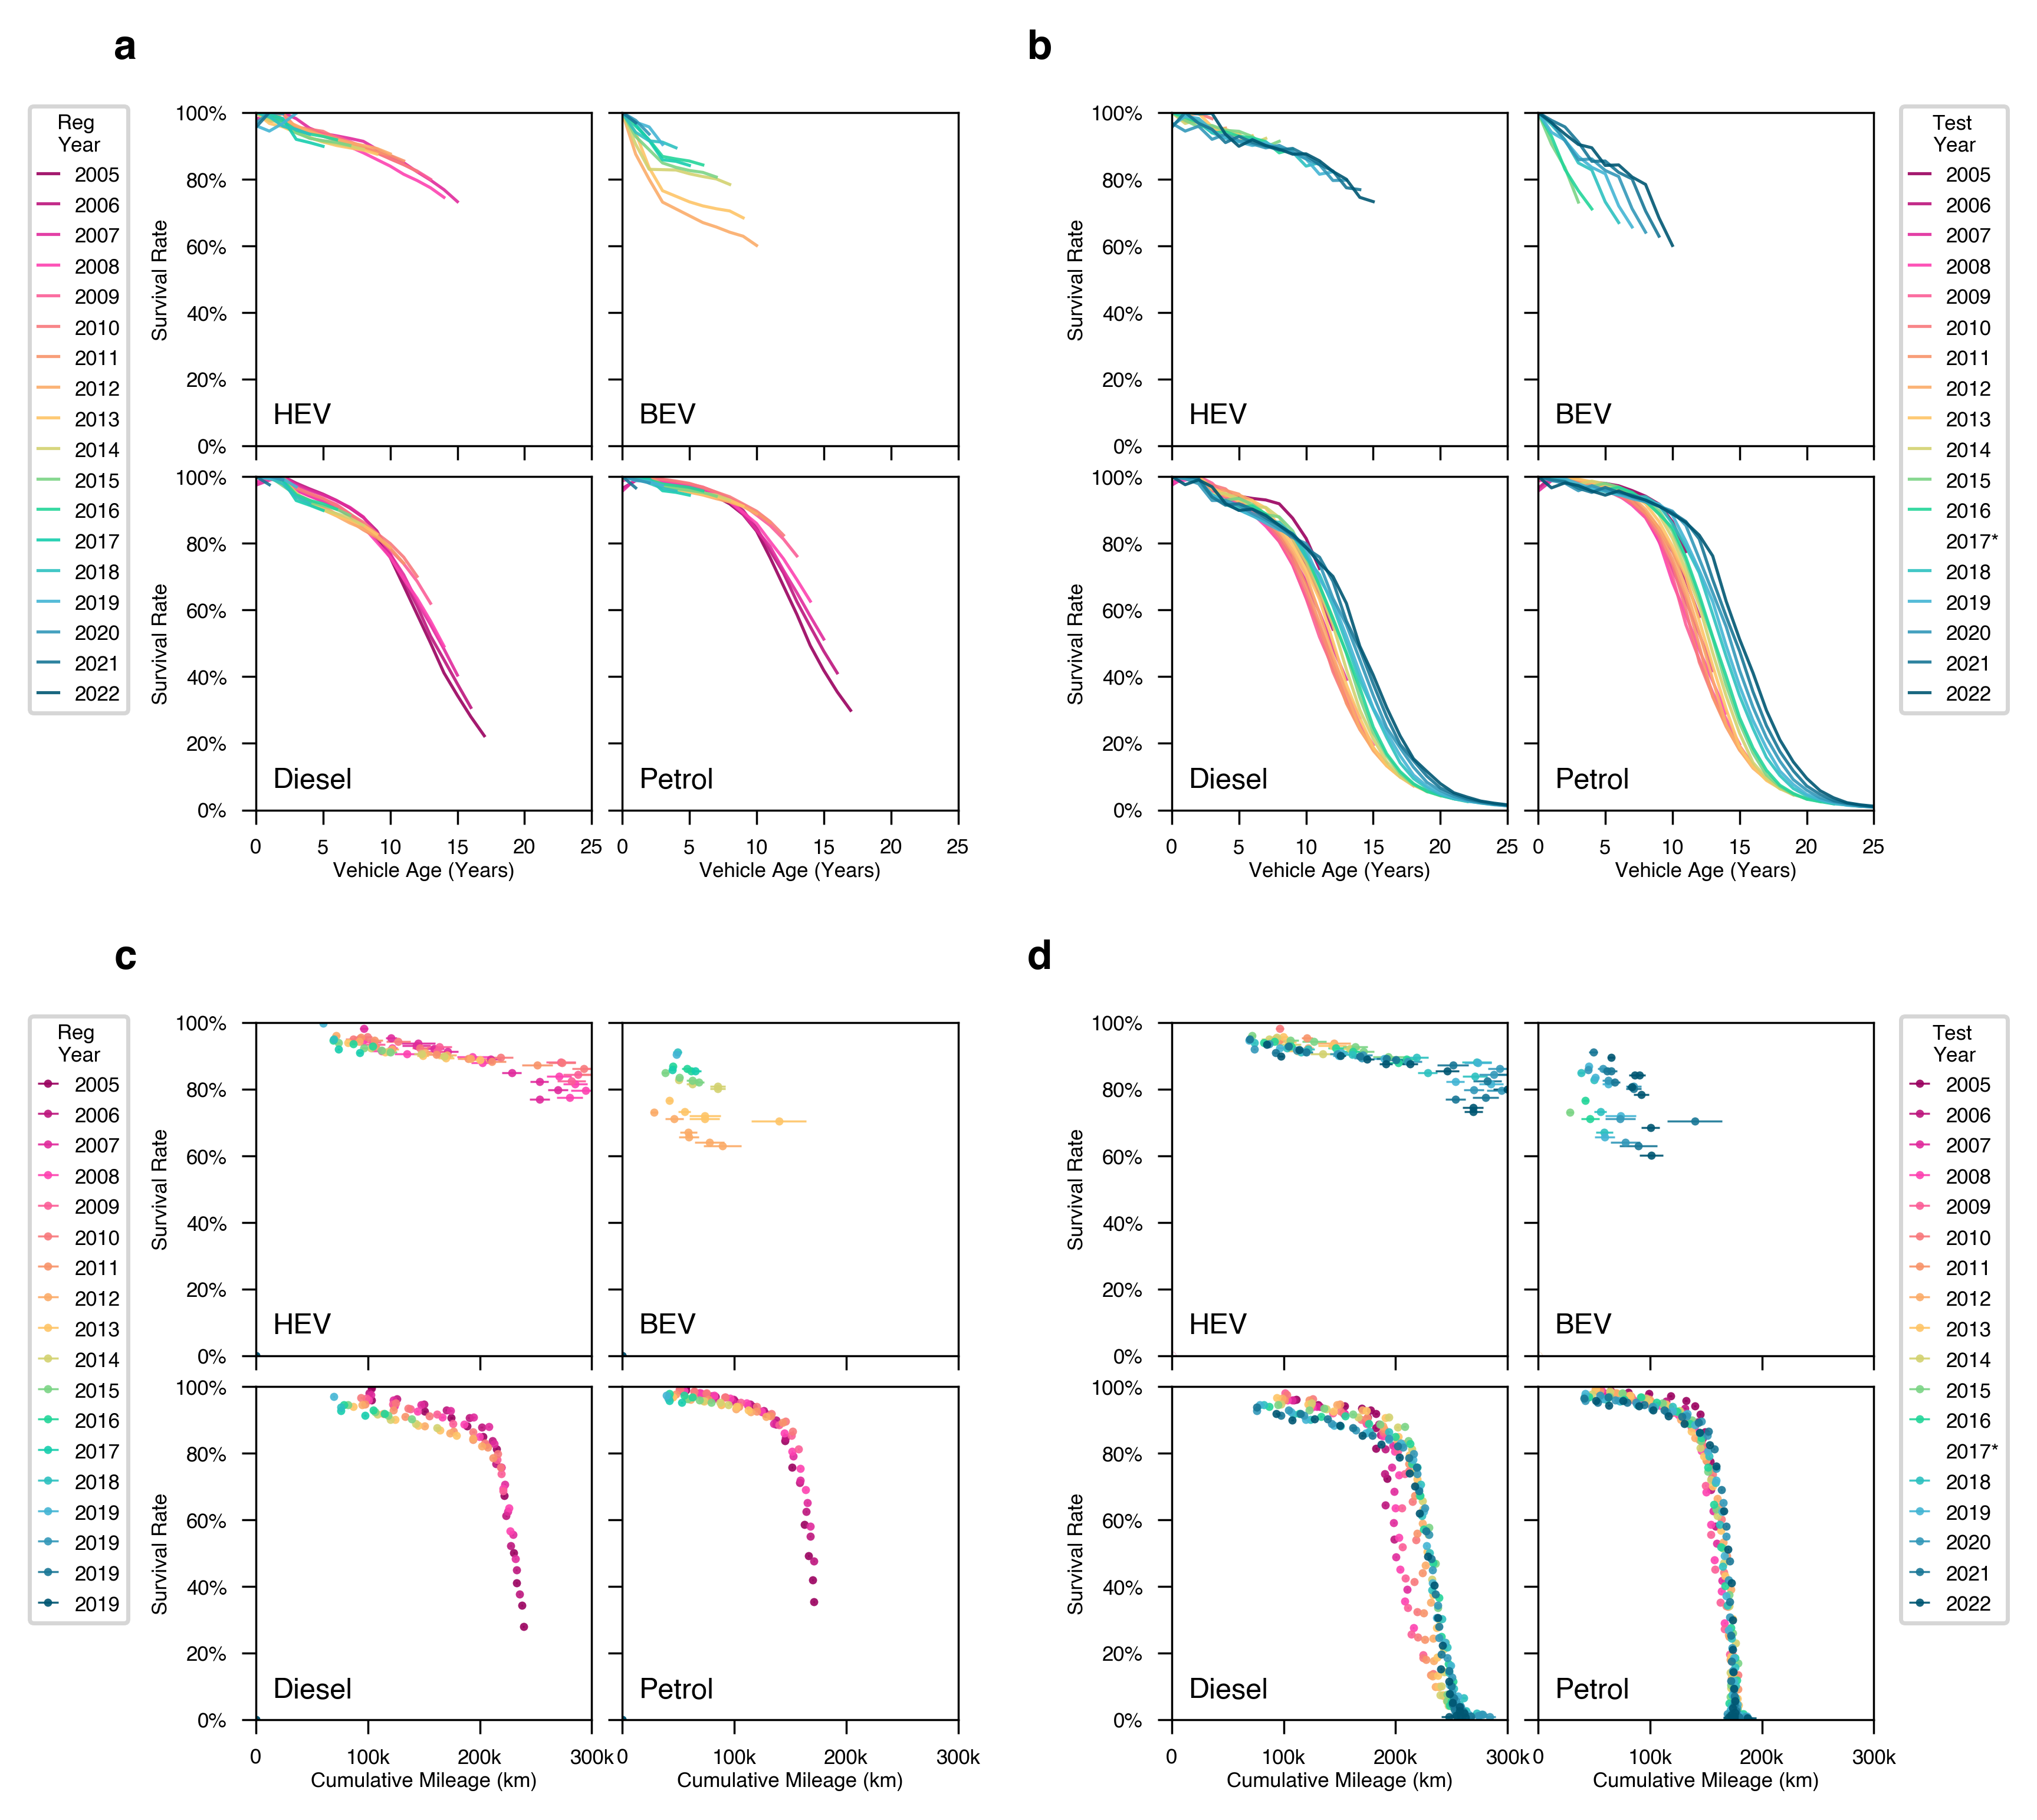

In [6]:
# Figure 4 - Survival

years = list(range(2005, 2023, 1))
# base_colors = ["#8F0000","#E4315B", "#F78C6B", "#FFD166", "#06D6A0", "#48B3D7", "#005672"]
base_colors = ["#9A015F","#FD3DB5", "#F78C6B", "#FFD166", "#06D6A0", "#48B3D7", "#005672"]
n = len(years)
colors = create_colormap(base_colors, n)
colors_lookup = {year : color for year, color in zip(years, colors)}

reg_years = list(range(2005, 2023, 1))
mot_years = list(range(2005, 2023, 1))

# Set up figure and axes - 2 rows of 2 figures (each with 4 sub-axes for fuel types)
fig = plt.figure(figsize=(7.08, 7.08), dpi=500)
gs = fig.add_gridspec(9, 9)

# First Row - Survival by Age
# Fig A - by Reg Year
ax1_a = fig.add_subplot(gs[0:2, 0:2])
ax2_a = fig.add_subplot(gs[0:2, 2:4])
ax3_a = fig.add_subplot(gs[2:4, 0:2])
ax4_a = fig.add_subplot(gs[2:4, 2:4])
a_axes = [ax1_a, ax2_a, ax3_a, ax4_a]
# Fig B - by Test Year
ax1_b = fig.add_subplot(gs[0:2, 5:7])
ax2_b = fig.add_subplot(gs[0:2, 7:9])
ax3_b = fig.add_subplot(gs[2:4, 5:7])
ax4_b = fig.add_subplot(gs[2:4, 7:9])
b_axes = [ax1_b, ax2_b, ax3_b, ax4_b]

# Second Row - Survival by Mileage
# Fig C - by Reg Year
ax1_c = fig.add_subplot(gs[5:7, 0:2])
ax2_c = fig.add_subplot(gs[5:7, 2:4])
ax3_c = fig.add_subplot(gs[7:9, 0:2])
ax4_c = fig.add_subplot(gs[7:9, 2:4])
c_axes = [ax1_c, ax2_c, ax3_c, ax4_c]
# Fig D - by Test Year
ax1_d = fig.add_subplot(gs[5:7, 5:7])
ax2_d = fig.add_subplot(gs[5:7, 7:9])
ax3_d = fig.add_subplot(gs[7:9, 5:7])
ax4_d = fig.add_subplot(gs[7:9, 7:9])
d_axes = [ax1_d, ax2_d, ax3_d, ax4_d]


filename = "MOT_data_to_VEH1111_format_mileage.csv"
fpath = os.path.join(script_path, "data", "survival_rate_data", filename)
df_mileage = pd.read_csv(fpath, engine="pyarrow")

filename = "MOT_data_to_VEH1111_format_mileage_stderr.csv"
fpath = os.path.join(script_path, "data", "survival_rate_data", filename)
df_mileage_stderr = pd.read_csv(fpath, engine="pyarrow")

filename = "MOT_and_DfT_combined_data.csv"
fpath = os.path.join(script_path, "data", "survival_rate_data", filename)
df = pd.read_csv(fpath, engine="pyarrow")

print("Plot a")
data_out = []
for fuel, ax in zip(fuels, a_axes):
    for year in reg_years:

        lower_year = get_fuel_cut_off_year(fuel)

        if year < lower_year:
            ax.plot([0,0], [0,0], color=colors_lookup[year], linewidth=0.75, label=year, alpha=0.9)
            continue

        if year <= 2005:
            start_year = 2006
        else:
            start_year = year

        years = [i for i in range(start_year, 2023, 1) if i != 2017]
        if len(df.loc[
            (df["year"].isin(years)) &
            (df["fuel"] == fuel),
            str(year)
            ]) > 1:

            percentage = df.loc[
                (df["year"].isin(years)) &
                (df["fuel"] == fuel),
                str(year)
                ].squeeze().to_list()

            age = [int(y) - year for y in years if y != 2017]

            color = colors_lookup[year]
            ax.plot(age, percentage, color=color, linewidth=0.75, label=year, alpha=0.9)

        else:
            ax.plot([0,0], [0,0], color=colors_lookup[year], linewidth=0.75, label=year, alpha=0.9)

        for i in range(len(age)):
            data_out.append([fuel, year, age[i], percentage[i]])

    ax.text(0.05, 0.05, f"{get_fuel_labels(fuel)}", transform=ax.transAxes, fontsize=7, verticalalignment='bottom', horizontalalignment='left')
    ax.set_xlim(0, 25)
    ax.set_ylim(0, 1)
    ax.set_xticks([0, 5, 10, 15, 20, 25])
    ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1])
    ax.set_yticklabels(["0%", "20%", "40%", "60%", "80%", "100%"])
    if fuel in ["car_diesel", "car_hev"]:
        ax.set_ylabel("Survival Rate", labelpad=1)
    else:
        ax.set_yticklabels([])
    if fuel in ["car_petrol", "car_diesel"]:
        ax.set_xlabel("Vehicle Age (Years)", labelpad=1)
    else:
        ax.set_xticklabels([])

ax1_a.legend(title="Reg\nYear",
            title_fontsize=5,
            loc="upper right",
            fontsize=5,
            handlelength=1,
            handleheight=1,
            bbox_to_anchor=(-0.35, 1.05)
)

data_out = pd.DataFrame(data_out, columns=["fuel", "reg_year", "age", "percentage"])
data_out.to_csv(os.path.join(script_path, "results", "figure_4_plot_a.csv"))

print("Plot b")
data_out = []
for fuel, ax in zip(fuels, b_axes):
    for year in mot_years:

        lower_year = get_fuel_cut_off_year(fuel)
        years = [str(i) for i in range(lower_year, year+1, 1)]
        if year < lower_year + 3:
            ax.plot([0,0], [0,0], color=colors_lookup[year], linewidth=0.75, label=year, alpha=0.9)
            continue

        percentage = df.loc[(df["year"] == year) & (df["fuel"] == fuel), years].squeeze().to_list()

        age = [i for i in range(0, len(percentage))]
        percentage.reverse()

        if year == 2017:
            ax.plot([0,0], [0,0], color="white", label="2017*")
            continue

        color = colors_lookup[year]
        ax.plot(age, percentage, color=color, linewidth=0.75, label=year, alpha=0.9)

        x = age
        y = percentage
        y_50 = 0.50
        age_50 = interpolate_data(x, y, y_50, interpolate_for='y')
        # print(f"\t{fuel}: {year}: Age at 50% scrappage for {get_fuel_labels(fuel)}: {age_50}")

        for i in range(len(age)):
            data_out.append([fuel, year, age[i], percentage[i]])

    ax.text(0.05, 0.05, f"{get_fuel_labels(fuel)}", transform=ax.transAxes, fontsize=7, verticalalignment='bottom', horizontalalignment='left')
    ax.set_xlim(0, 25)
    ax.set_ylim(0, 1)
    ax.set_xticks([0, 5, 10, 15, 20, 25])
    ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1])
    ax.set_yticklabels(["0%", "20%", "40%", "60%", "80%", "100%"])
    if fuel in ["car_diesel", "car_hev"]:
        ax.set_ylabel("Survival Rate", labelpad=1)
    else:
        ax.set_yticklabels([])
    if fuel in ["car_petrol", "car_diesel"]:
        ax.set_xlabel("Vehicle Age (Years)", labelpad=1)
    else:
        ax.set_xticklabels([])

ax2_b.legend(title="Test\nYear",
            title_fontsize=5,
            loc="upper left",
            fontsize=5,
            handlelength=1,
            handleheight=1,
            bbox_to_anchor=(1.05, 1.05)
)

data_out = pd.DataFrame(data_out, columns=["fuel", "test_year", "age", "percentage"])
data_out.to_csv(os.path.join(script_path, "results", "figure_4_plot_b.csv"))

print("Plot c")
data_out = []
for fuel, ax in zip(fuels, c_axes):
    for year in reg_years:

        lower_year = get_fuel_cut_off_year(fuel)
        if year < lower_year:
            label = year
            ax.errorbar([0,0], [0,0], xerr=[0,0], color=colors_lookup[year], alpha=0.9, linewidth=0.5, marker='o', markersize=2, linestyle='none', markeredgecolor='none', label=label)
            continue
        if year <= 2005:
            start_year = 2006
        else:
            start_year = year + 3
        years = [i for i in range(start_year, 2023, 1) if i != 2017]

        if len(df.loc[(df["year"].isin(years)) & (df["fuel"] == fuel), str(year)]) > 1:
            percentage = df.loc[(df["year"].isin(years)) & (df["fuel"] == fuel), str(year)].squeeze().to_list()
            mileage = df_mileage.loc[(df_mileage["year"].isin(years)) & (df_mileage["fuel"] == fuel), str(year)].squeeze().to_list()
            stderr = df_mileage_stderr.loc[(df_mileage_stderr["year"].isin(years)) & (df_mileage_stderr["fuel"] == fuel), str(year)].squeeze().to_list()
            age = [int(y) - year for y in years if y != 2017]

            label = year
            ax.errorbar(mileage[:-1], percentage[:-1], xerr=stderr[:-1], color=colors_lookup[year], alpha=0.9, linewidth=0.5, marker='o', markersize=2, linestyle='none', markeredgecolor='none', label=label)
            mileage = mileage[:-1]
            percentage = percentage[:-1]
            stderr = stderr[:-1]

        elif len(df.loc[(df["year"].isin(years)) & (df["fuel"] == fuel), str(year)]) > 0:
            percentage = df.loc[(df["year"].isin(years)) & (df["fuel"] == fuel), str(year)].squeeze()
            mileage = df_mileage.loc[(df_mileage["year"].isin(years)) & (df_mileage["fuel"] == fuel), str(year)].squeeze()
            stderr = df_mileage_stderr.loc[(df_mileage_stderr["year"].isin(years)) & (df_mileage_stderr["fuel"] == fuel), str(year)].squeeze()
            age = [int(y) - year for y in years if y != 2017]

            label = year
            ax.errorbar(mileage, percentage, xerr=stderr, color=colors_lookup[year], alpha=0.9, linewidth=0.5, marker='o', markersize=2, linestyle='none', markeredgecolor='none', label=label)

        else:
            ax.errorbar([0,0], [0,0], xerr=[0,0], color=colors_lookup[year], alpha=0.9, linewidth=0.5, marker='o', markersize=2, linestyle='none', markeredgecolor='none', label=label)

        try:
            for i in range(len(mileage)):
                data_out.append([fuel, year, mileage[i], percentage[i], stderr[i]])
        except:
            data_out.append([fuel, year, mileage, percentage, stderr])

    ax.text(0.05, 0.05, f"{get_fuel_labels(fuel)}", transform=ax.transAxes, fontsize=7, verticalalignment='bottom', horizontalalignment='left')
    ax.set_xlim(0, 300_000)
    ax.set_ylim(0, 1)
    ax.set_xticks([0, 100_000, 200_000, 300_000])
    ax.set_xticklabels(["0", "100k", "200k", "300k"])
    ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1])
    ax.set_yticklabels(["0%", "20%", "40%", "60%", "80%", "100%"])
    if fuel in ["car_diesel", "car_hev"]:
        ax.set_ylabel("Survival Rate", labelpad=1)
    else:
        ax.set_yticklabels([])
    if fuel in ["car_petrol", "car_diesel"]:
        ax.set_xlabel("Cumulative Mileage (km)", labelpad=1)
    else:
        ax.set_xticklabels([])
        
ax1_c.legend(title="Reg\nYear",
            title_fontsize=5,
            loc="upper right",
            fontsize=5,
            handlelength=1,
            handleheight=1,
            bbox_to_anchor=(-0.35, 1.05)
)
data_out = pd.DataFrame(data_out, columns=["fuel", "reg_year", "mileage", "percentage", "mileage_stderr"])
data_out.to_csv(os.path.join(script_path, "results", "figure_4_plot_c.csv"))

print("Plot d")
data_out = []
for fuel, ax in zip(["car_hev", "car_bev", "car_diesel", "car_petrol"], d_axes):
    for year in mot_years:

        lower_year = get_fuel_cut_off_year(fuel)
        upper_year = year
        if upper_year > 2021:
            upper_year = 2021
        years = [str(i) for i in range(lower_year, upper_year+1, 1)]
        if year < lower_year + 3:
            label = year
            ax.errorbar([0,0], [0,0], xerr=[0,0], color=colors_lookup[year], alpha=0.9, linewidth=0.5, marker='o', markersize=2, linestyle='none', markeredgecolor='none', label=label)
            continue

        if year == 2017:
            ax.errorbar([0,0], [0,0], xerr=[0,0], color="white", alpha=0.9, linewidth=0.5, marker='o', markersize=2, linestyle='none', markeredgecolor='none', label="2017*")
            continue

        # print(df_mileage.loc[(df_mileage["year"] == year) & (df_mileage["fuel"] == fuel), years])
        # print(fuel, year, df.loc[(df["year"] == year) & (df["fuel"] == fuel), years])
        percentage = df.loc[(df["year"] == year) & (df["fuel"] == fuel), years].squeeze().to_list()
        mileage = df_mileage.loc[(df_mileage["year"] == year) & (df_mileage["fuel"] == fuel), years].squeeze().to_list()
        stderr = df_mileage_stderr.loc[(df_mileage_stderr["year"] == year) & (df_mileage_stderr["fuel"] == fuel), years].squeeze().to_list()
        percentage.reverse()
        mileage.reverse()
        stderr.reverse()
        color = colors_lookup[year]

        mileage = mileage[3:]
        percentage = percentage[3:]
        stderr = stderr[3:]
        label = year
        ax.errorbar(mileage, percentage, xerr=stderr, color=color, alpha=0.9, linewidth=0.5, marker='o', markersize=2, linestyle='none', markeredgecolor='none', label=label)

        x = mileage
        y = percentage
        y_50 = 0.50
        age_50 = interpolate_data(x, y, y_50, interpolate_for='y')
        # print(f"\t{fuel}: {year}: Mileage at 50% scrappage for {get_fuel_labels(fuel)}: {age_50}")

        for i in range(len(mileage)):
            data_out.append([fuel, year, mileage[i], percentage[i], stderr[i]])

    ax.text(0.05, 0.05, f"{get_fuel_labels(fuel)}", transform=ax.transAxes, fontsize=7, verticalalignment='bottom', horizontalalignment='left')
    ax.set_xlim(0, 300_000)
    ax.set_ylim(0, 1)
    ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1])
    ax.set_yticklabels(["0%", "20%", "40%", "60%", "80%", "100%"])
    ax.set_xticks([0, 100_000, 200_000, 300_000])
    ax.set_xticklabels(["0", "100k", "200k", "300k"])
    if fuel in ["car_diesel", "car_hev"]:
        ax.set_ylabel("Survival Rate", labelpad=1)
    else:
        ax.set_yticklabels([])
    if fuel in ["car_petrol", "car_diesel"]:
        ax.set_xlabel("Cumulative Mileage (km)", labelpad=1)
    else:
        ax.set_xticklabels([])

ax2_d.legend(title="Test\nYear",
            title_fontsize=5,
            loc="upper left",
            fontsize=5,
            handlelength=1,
            handleheight=1,
            bbox_to_anchor=(1.05, 1.05)
)

data_out = pd.DataFrame(data_out, columns=["fuel", "test_year", "mileage", "percentage", "mileage_stderr"])
data_out.to_csv(os.path.join(script_path, "results", "figure_4_plot_d.csv"))

# Panel labels
for ax, c in zip(
    [ax1_a, ax1_b, ax1_c, ax1_d],
    ["a", "b", "c", "d"]
    ):
    ax.text(-0.355, 1.25, c, transform=ax.transAxes, fontsize=10, fontweight='bold', va='top', ha='right')

plt.savefig(os.path.join(script_path, "results", "figure_4.pdf"), dpi=500, format='pdf')

Plot a
Plot c
Plot b
Plot d


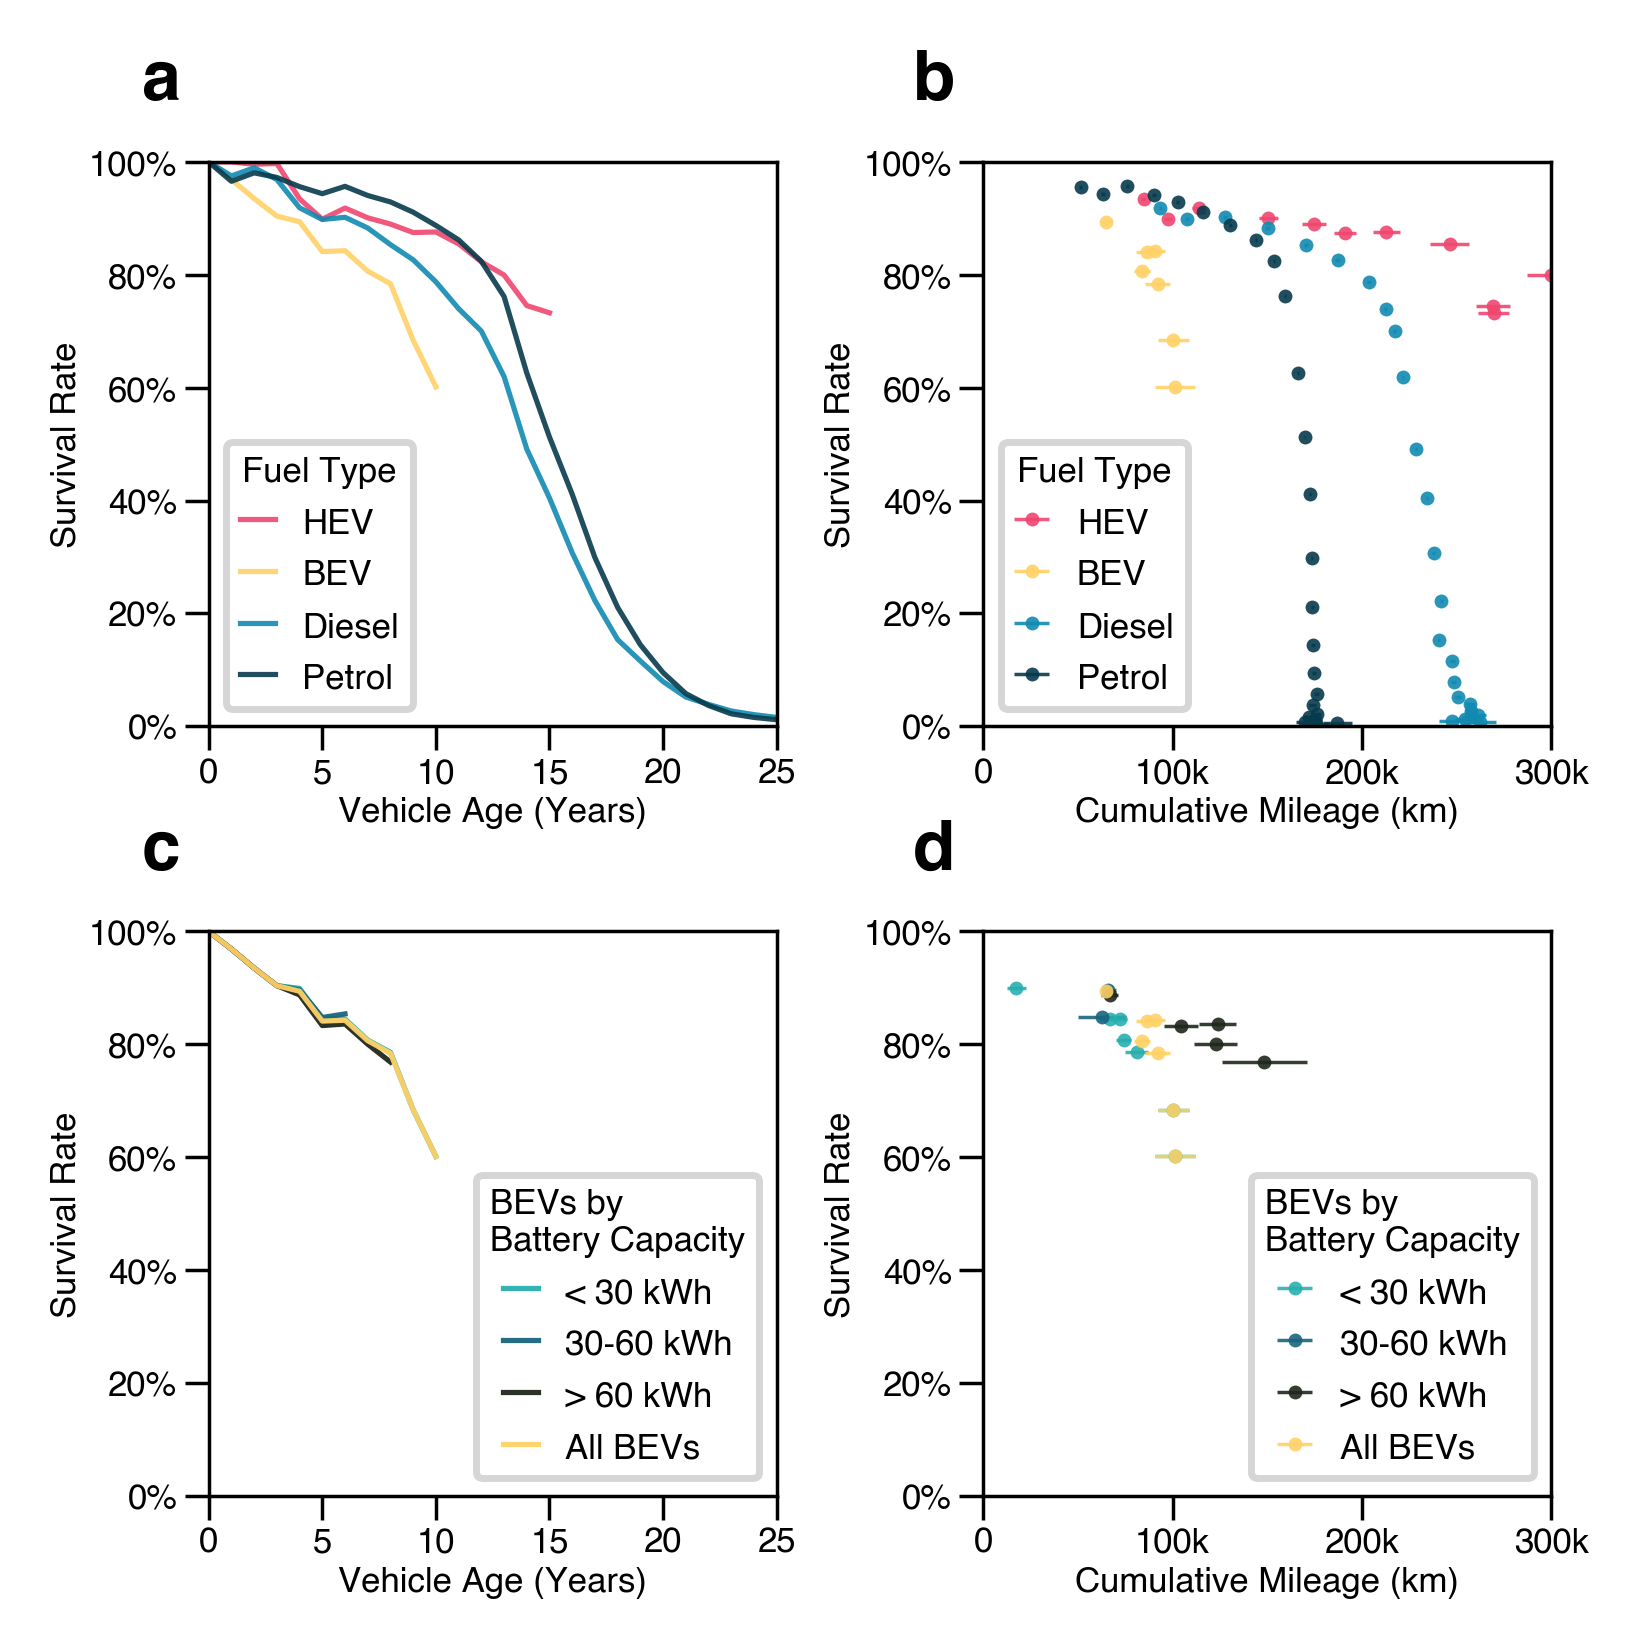

In [7]:
# Figure 5 - Survival by fuel type and BEV battery capacity

fuels = ["car_hev", "car_bev", "car_diesel", "car_petrol"]
fuel_colours = ["#ef476f", "#ffd166", "#118ab2", "#073b4c"]
fuel_colors_lookup = {fuel: color for fuel, color in zip(fuels, fuel_colours)}

fuels_battery = [ "car_bev_battery_30", "car_bev_battery_60", "car_bev_battery_100", "car_bev",]
fuel_colours_battery = [ "#28AFB0", "#19647E", "#1F271B", "#ffd166",]
fuel_colors_lookup_battery = {fuel: color for fuel, color in zip(fuels_battery, fuel_colours_battery)}

# Compact 2x2 layout to match the updated split-figure formatting
fig = plt.figure(figsize=(3.46457, 3.46457), dpi=500)  # 88mm x 88mm
gs = fig.add_gridspec(9, 9, wspace=0.5, hspace=0.5)

ax_a = fig.add_subplot(gs[0:4, 0:4])  # old c-top (fuel, age)
ax_b = fig.add_subplot(gs[0:4, 5:9])  # old c-bottom (BEV battery, age)
ax_c = fig.add_subplot(gs[5:9, 0:4])  # old f-top (fuel, mileage)
ax_d = fig.add_subplot(gs[5:9, 5:9])  # old f-bottom (BEV battery, mileage)

# Base survival data
filename = "MOT_and_DfT_combined_data.csv"
fpath = os.path.join(script_path, "data", "survival_rate_data", filename)
df = pd.read_csv(fpath, engine="pyarrow")

# ---- Plot a (old c-top) ----
print("Plot a")
ax = ax_a
data_out = []
for fuel in fuels:
    color = fuel_colors_lookup[fuel]
    year = 2022
    lower_year = get_fuel_cut_off_year(fuel)
    years = [str(i) for i in range(lower_year, year + 1, 1)]

    percentage = df.loc[(df["year"] == year) & (df["fuel"] == fuel), years].squeeze().to_list()
    age = [i for i in range(0, len(percentage))]
    percentage.reverse()

    ax.plot(age, percentage, color=color, linewidth=0.75, label=f"{get_fuel_labels(fuel)}", alpha=0.9)

    x = age
    y = percentage
    y_50 = 0.50
    age_50 = interpolate_data(x, y, y_50, interpolate_for="y")
    # print(f"\t{fuel}: Age at 50% scrappage for {get_fuel_labels(fuel)}: {age_50}")

    for i in range(len(age)):
        data_out.append([fuel, age[i], percentage[i]])

ax.set_xlim(0, 25)
ax.set_ylim(0, 1)
ax.set_xticks([0, 5, 10, 15, 20, 25])
ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1])
ax.set_yticklabels(["0%", "20%", "40%", "60%", "80%", "100%"])
ax.set_ylabel("Survival Rate", labelpad=1)
ax.set_xlabel("Vehicle Age (Years)", labelpad=1)
ax.legend(
    title="Fuel Type",
    title_fontsize=5,
    fontsize=5,
    loc="lower left",
    handleheight=1,
    handlelength=1
)

data_out = pd.DataFrame(data_out, columns=["fuel", "age", "percentage"])
data_out.to_csv(os.path.join(script_path, "results", "figure_5_plot_a.csv"))

# ---- Plot b (old c-bottom) ----
print("Plot c")
fname = "MOT_and_DfT_combined_data_bev_disag.csv"
path = os.path.join(script_path, "data", "survival_rate_data", fname)
df = pd.read_csv(path, engine="pyarrow")

ax = ax_c
data_out = []
for fuel in fuels_battery:
    color = fuel_colors_lookup_battery[fuel]
    year = 2022
    lower_year = get_fuel_cut_off_year("car_bev")
    years = [str(i) for i in range(lower_year, year + 1, 1)]

    percentage = df.loc[(df["year"] == year) & (df["fuel"] == fuel), years].squeeze().to_list()
    age = [i for i in range(0, len(percentage))]
    percentage.reverse()

    age_plot = []
    percentage_plot = []
    for a, p in zip(age, percentage):
        if p == 0.0:
            break
        age_plot.append(a)
        percentage_plot.append(p)

    if fuel == "car_bev":
        label = f"All {get_fuel_labels(fuel)}s"
    else:
        label = f"{get_fuel_labels_disag(fuel)}"

    age = age_plot
    percentage = percentage_plot

    ax.plot(age, percentage, color=color, linewidth=0.75, label=label, alpha=0.95)

    for i in range(len(age)):
        data_out.append([fuel, age[i], percentage[i]])

ax.set_xlim(0, 25)
ax.set_ylim(0, 1)
ax.set_xticks([0, 5, 10, 15, 20, 25])
ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1])
ax.set_yticklabels(["0%", "20%", "40%", "60%", "80%", "100%"])
ax.tick_params(axis="both", pad=1)
ax.set_ylabel("Survival Rate", labelpad=1)
ax.set_xlabel("Vehicle Age (Years)", labelpad=1)
ax.legend(
    title="BEVs by\nBattery Capacity",
    title_fontsize=5,
    fontsize=5,
    loc="lower right",
    handleheight=1,
    handlelength=1,
)

# Shared top-row legend (fuel type) placed on right panel to match split-figure style
handles_a, labels_a = ax_a.get_legend_handles_labels()
ax_b.legend(
    handles_a,
    labels_a,
    title="Fuel Type in\nTest Year 2022",
    title_fontsize=5,
    fontsize=5,
    loc="lower right",
    handleheight=1,
    handlelength=1,
)

data_out = pd.DataFrame(data_out, columns=["fuel", "age", "percentage"])
data_out.to_csv(os.path.join(script_path, "results", "figure_5_plot_c.csv"))

# Continue Figure 5 - lower row from old Figure 3 panel f (top and bottom)

# Re-load base survival and mileage data
filename = "MOT_and_DfT_combined_data.csv"
fpath = os.path.join(script_path, "data", "survival_rate_data", filename)
df = pd.read_csv(fpath, engine="pyarrow")

filename = "MOT_data_to_VEH1111_format_mileage.csv"
fpath = os.path.join(script_path, "data", "survival_rate_data", filename)
df_mileage = pd.read_csv(fpath, engine="pyarrow")

filename = "MOT_data_to_VEH1111_format_mileage_stderr.csv"
fpath = os.path.join(script_path, "data", "survival_rate_data", filename)
df_mileage_stderr = pd.read_csv(fpath, engine="pyarrow")

# ---- Plot b (old f-top) ----
print("Plot b")
ax = ax_b
data_out = []
for fuel in ["car_hev", "car_bev", "car_diesel", "car_petrol"]:
    year = 2022

    lower_year = get_fuel_cut_off_year(fuel)
    upper_year = year
    if upper_year > 2021:
        upper_year = 2021
    years = [str(i) for i in range(lower_year, upper_year + 1, 1)]

    percentage = df.loc[(df["year"] == year) & (df["fuel"] == fuel), years].squeeze().to_list()
    mileage = df_mileage.loc[(df_mileage["year"] == year) & (df_mileage["fuel"] == fuel), years].squeeze().to_list()
    stderr = df_mileage_stderr.loc[(df_mileage_stderr["year"] == year) & (df_mileage_stderr["fuel"] == fuel), years].squeeze().to_list()
    percentage.reverse()
    mileage.reverse()
    stderr.reverse()

    mileage = mileage[3:]
    percentage = percentage[3:]
    stderr = stderr[3:]

    label = get_fuel_labels(fuel)
    ax.errorbar(
        mileage,
        percentage,
        xerr=stderr,
        color=fuel_colors_lookup[fuel],
        alpha=0.9,
        linewidth=0.5,
        marker="o",
        markersize=2,
        linestyle="none",
        markeredgecolor="none",
        label=label,
    )

    x = mileage
    y = percentage
    y_50 = 0.50
    mileage_50 = interpolate_data(x, y, y_50, interpolate_for="y")
    # print(f"\t{fuel}: Mileage at 50% scrappage for {get_fuel_labels(fuel)}: {mileage_50}")

    for i in range(len(mileage)):
        data_out.append([fuel, mileage[i], percentage[i], stderr[i]])

ax.set_xlim(0, 300_000)
ax.set_ylim(0, 1)
ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1])
ax.set_yticklabels(["0%", "20%", "40%", "60%", "80%", "100%"])
ax.set_xticks([0, 100_000, 200_000, 300_000])
ax.set_xticklabels(["0", "100k", "200k", "300k"])
ax.set_ylabel("Survival Rate", labelpad=1)
ax.set_xlabel("Cumulative Mileage (km)", labelpad=1)
ax.legend(
    title="Fuel Type",
    title_fontsize=5,
    loc="lower left",
    fontsize=5,
    handleheight=1,
    handlelength=1,
)

data_out = pd.DataFrame(data_out, columns=["fuel", "mileage", "percentage", "mileage_stderr"])
data_out.to_csv(os.path.join(script_path, "results", "figure_5_plot_b.csv"))

# ---- Plot d (old f-bottom) ----
print("Plot d")
fname = "MOT_data_to_VEH1111_format_mileage_bev_disag.csv"
path = os.path.join(script_path, "data", "survival_rate_data", fname)
df_mileage = pd.read_csv(path, engine="pyarrow")

fname = "MOT_data_to_VEH1111_format_mileage_stderr_bev_disag.csv"
path = os.path.join(script_path, "data", "survival_rate_data", fname)
df_mileage_stderr = pd.read_csv(path, engine="pyarrow")

fname = "MOT_and_DfT_combined_data_bev_disag.csv"
path = os.path.join(script_path, "data", "survival_rate_data", fname)
df = pd.read_csv(path, engine="pyarrow")

ax = ax_d
data_out = []
for fuel in fuels_battery:
    year = 2022

    lower_year = get_fuel_cut_off_year("car_bev")
    upper_year = year
    if upper_year > 2021:
        upper_year = 2021
    years = [str(i) for i in range(lower_year, upper_year + 1, 1)]

    percentage = df.loc[(df["year"] == year) & (df["fuel"] == fuel), years].squeeze().to_list()
    mileage = df_mileage.loc[(df_mileage["year"] == year) & (df_mileage["fuel"] == fuel), years].squeeze().to_list()
    stderr = df_mileage_stderr.loc[(df_mileage_stderr["year"] == year) & (df_mileage_stderr["fuel"] == fuel), years].squeeze().to_list()
    percentage.reverse()
    mileage.reverse()
    stderr.reverse()

    mileage = mileage[3:]
    percentage = percentage[3:]
    stderr = stderr[3:]

    if fuel == "car_bev":
        label = f"{get_fuel_labels(fuel)}"
    else:
        label = f"{get_fuel_labels_disag(fuel)}"

    if fuel == "car_bev":
        ax.errorbar(
            mileage,
            percentage,
            xerr=stderr,
            color=fuel_colors_lookup_battery[fuel],
            alpha=0.9,
            linewidth=0.5,
            marker="o",
            markersize=2,
            linestyle="none",
            markeredgecolor="none",
            label=f"All {label}s",
        )
    
    else:
        
        ax.errorbar(
            mileage,
            percentage,
            xerr=stderr,
            color=fuel_colors_lookup_battery[fuel],
            alpha=0.9,
            linewidth=0.5,
            marker="o",
            markersize=2,
            linestyle="none",
            markeredgecolor="none",
            label=label,
        )

    for i in range(len(mileage)):
        data_out.append([fuel, mileage[i], percentage[i], stderr[i]])

ax.set_xlim(0, 300_000)
ax.set_ylim(0, 1)
ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1])
ax.set_yticklabels(["0%", "20%", "40%", "60%", "80%", "100%"])
ax.set_xticks([0, 100_000, 200_000, 300_000])
ax.set_xticklabels(["0", "100k", "200k", "300k"])
ax.set_xlabel("Cumulative Mileage (km)", labelpad=1)
ax.set_ylabel("Survival Rate", labelpad=1)

ax.legend(
    title="BEVs by\nBattery Capacity",
    title_fontsize=5,
    loc="lower right",
    fontsize=5,
    handleheight=1,
    handlelength=1,
)

data_out = pd.DataFrame(data_out, columns=["fuel", "mileage", "percentage", "mileage_stderr"])
data_out.to_csv(os.path.join(script_path, "results", "figure_5_plot_d.csv"))

# Panel labels and spacing
for ax, c in zip([ax_a, ax_b, ax_c, ax_d], ["a", "b", "c", "d"]):
    ax.text(-0.05, 1.2, c, transform=ax.transAxes, fontsize=10, fontweight="bold", va="top", ha="right")
    ax.tick_params(axis="both", pad=1)

plt.savefig(os.path.join(script_path, "results", "figure_5.pdf"), dpi=500, format="pdf")

In [11]:
# SI Figure 1: Repeat of Figure 2 using VEH1111 and using reg years

# Colours, fuels, and MOT years to iterate over and use for plotting
mot_years = [2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2022, 2022, 2023, 2024]
mot_colors = ["#010000","#38030F","#5E0A1E","#A72241", "#EF476F", "#F78C6B", "#FFD166", "#CFFF66", "#06D6A0", "#48B3D7", "#0A7EA5", "#093E50", "#001B24"]
mot_colors_lookup = {year : color for year, color in zip(mot_years, mot_colors)}

fuels = ["car_hev", "car_bev", "car_diesel", "car_petrol"]
fuel_colours = ["#ef476f", "#ffd166","#118ab2", "#073b4c"]
fuel_colors_lookup = {fuel : color for fuel, color in zip(fuels, fuel_colours)}

fuels_battery = ["car_bev", "car_bev_battery_30", "car_bev_battery_60", "car_bev_battery_100"]
fuel_colours = ["#ffd166","#28AFB0", "#19647E", "#1F271B"]
fuel_colors_lookup_battery = {fuel : color for fuel, color in zip(fuels_battery, fuel_colours)}

fuels_make = ["car_bev", "car_bev_make_TESLA", "car_bev_make_NISSAN", "car_bev_make_RENAULT", "car_bev_make_BMW", "car_bev_make_HYUNDAI", "car_bev_make_KIA"] 
fuel_colours = ["#ffd166", "#CA4733", "black", "#E5D1D0", "#3092BC", "#C7F0BD", "#4C3549"]
fuel_colors_lookup_make = {fuel : color for fuel, color in zip(fuels_make, fuel_colours)}

reg_years = list(range(2000, 2025, 1))
base_colors = ["#38030F","#5E0A1E","#A72241", "#EF476F", "#F78C6B", "#FFD166", "#06D6A0", "#48B3D7", "#0A7EA5", "#093E50", "#001B24"]
n = len(reg_years)
colors = create_colormap(base_colors, n)
colors_lookup = {year : color for year, color in zip(reg_years, colors)}

# Set up figure and axes - 2 rows of 4 figures
fig = plt.figure(figsize=(10,10), dpi=1000)
gs = fig.add_gridspec(9, 9)
# Fig A
ax1 = fig.add_subplot(gs[0:2, 0:2])
ax2 = fig.add_subplot(gs[0:2, 2:4])
ax3 = fig.add_subplot(gs[2:4, 0:2])
ax4 = fig.add_subplot(gs[2:4, 2:4])
axes_a= [ax1, ax2, ax3, ax4]
# Fig B
ax2_1 = fig.add_subplot(gs[0:2, 5:7])
ax2_2 = fig.add_subplot(gs[0:2, 7:9])
ax2_3 = fig.add_subplot(gs[2:4, 5:7])
ax2_4 = fig.add_subplot(gs[2:4, 7:9])
axes_b = [ax2_1, ax2_2, ax2_3, ax2_4]
# Fig C
ax3_1 = fig.add_subplot(gs[5:7, 0:2])
ax3_2 = fig.add_subplot(gs[5:7, 2:4])
ax3_3 = fig.add_subplot(gs[7:9, 0:2])
ax3_4 = fig.add_subplot(gs[7:9, 2:4])
axes_c = [ax3_1, ax3_2, ax3_3, ax3_4]
# Fig D
ax4_1 = fig.add_subplot(gs[5:7, 5:7])
ax4_2 = fig.add_subplot(gs[5:7, 7:9])
ax4_3 = fig.add_subplot(gs[7:9, 5:7])
ax4_4 = fig.add_subplot(gs[7:9, 7:9])
axes_d = [ax4_1, ax4_2, ax4_3, ax4_4]

folder = "survival_rate_data"
fname = "MOT_and_DfT_combined_data.csv"
fpath = os.path.join(script_path, "data", folder, fname)
df = pd.read_csv(fpath)

print("Plot b")
for fuel, ax in zip(fuels, axes_b):
    for year in range(2006, 2025, 1):
            
        lower_year = get_fuel_cut_off_year(fuel)
        years = [str(i) for i in range(lower_year, year+1, 1)]
        
        lower_year = get_fuel_cut_off_year(fuel)
        
        if year < (lower_year + 3):
            # add fake line to fill out legend
            ax.plot([0,0], [0,0], color =colors_lookup[year], linewidth=0.75, label=year, alpha=0.75)
            continue
        
        if len(df.loc[
            (df["year"] == year) & # year is date
            (df["fuel"] == fuel)]) < 1:
            # add fake line to fill out legend
            ax.plot([0,0], [0,0], color=colors_lookup[year], linewidth=0.75, label=year, alpha=0.75)
            continue

        percentage = df.loc[
            (df["year"] == year) & # year is date
            (df["fuel"] == fuel),
            years
            ].squeeze().to_list()
        
        age = [i for i in range(0, len(percentage))]
        percentage.reverse()
        
        # # 2017 has missing data causing a step change in the data from age 4 to 5 (i.e., when swicthing to the MOT data)
        if year == 2017:
            ax.plot([0,0], [0,0], color = "white", label="2017*")
            continue
        elif year == 2023:
            ax.plot([0,0], [0,0], color = "white", label="2023†")
            continue
        elif year == 2024:
            ax.plot([0,0], [0,0], color = "white", label="2024†")
            continue
        
        color = colors_lookup[year]
        ax.plot(age, percentage, color=color, linewidth=0.75, label=year, alpha=0.75)
        
        # Now find the age at which 50% of vehicles have been scrapped using interpolate_data()
        x = age
        y = percentage
        y_50 = 0.50
        age_50 = interpolate_data(x, y, y_50, interpolate_for='y')
        # print(f"\tMOT, {fuel}: {year}: Age at 50% scrappage for {get_fuel_labels(fuel)}: {age_50}")

        
        # fuel_survival_data[year][fuel] = {"age" : age, "percentage" : percentage}
            
    ax.text(0.05, 0.05, f"{get_fuel_labels(fuel)}", transform=ax.transAxes, fontsize=14, verticalalignment='bottom', horizontalalignment='left')
    ax.set_xlim(0,25)
    ax.set_ylim(0,1)
    ax.set_xticks([0, 5, 10, 15, 25])
    ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1])
    ax.set_yticklabels(["0%", "20%", "40%", "60%", "80%", "100%"])
    
    
    if fuel in ["car_diesel", "car_hev"]:
        ax.set_ylabel("Survival Rate")
    else:
        ax.set_yticklabels([])
        
        
    if fuel in ["car_petrol", "car_diesel"]:
        ax.set_xlabel("Vehicle Age (Years)")
    else:
        ax.set_xticklabels([])
    
# Fake line for better legend
ax2_2.legend(title ="MOT Data\nTest Year",
            title_fontsize=9,
            loc='upper right', 
            fontsize=6, 
            handleheight=1, 
            handlelength=1)

folder = "survival_rate_data"
fname = "VEH1111_Summary_Data_Percentages.csv"
fpath = os.path.join(script_path, "data", folder, fname)
df = pd.read_csv(fpath)

print("Plot d")
for fuel, ax in zip(fuels, axes_d):
    for year in range(2000, 2025, 1):
            
        lower_year = get_fuel_cut_off_year(fuel)
        years = [str(i) for i in range(lower_year, year+1, 1)]
        
        lower_year = get_fuel_cut_off_year(fuel)
        
        if year <= lower_year:
            # add fake line to fill out legend
            ax.plot([0,0], [0,0], color=colors_lookup[year], linewidth=0.75, label=year, alpha=0.75)
            continue
    
        if len(df.loc[
            (df["year"] == year) & # year is date
            (df["fuel"] == fuel)]) < 1:
            # add fake line to fill out legend
            ax.plot([0,0], [0,0], color=colors_lookup[year], linewidth=0.75, label=year, alpha=0.75)
            continue

        percentage = df.loc[
            (df["year"] == year) & # year is date
            (df["fuel"] == fuel),
            years
            ].squeeze().to_list()

        age = [i for i in range(0, len(percentage))]
        percentage.reverse()
        
        color = colors_lookup[year]
        ax.plot(age, percentage, color=color, linewidth=0.75, label=year, alpha=0.75)
        
        # Now find the age at which 50% of vehicles have been scrapped using interpolate_data()
        x = age
        y = percentage
        y_50 = 0.50
        age_50 = interpolate_data(x, y, y_50, interpolate_for='y')
        # print(f"\tVEH1111, {fuel}: {year}: Age at 50% scrappage for {get_fuel_labels(fuel)}: {age_50}")
        
    ax.text(0.05, 0.05, f"{get_fuel_labels(fuel)}", transform=ax.transAxes, fontsize=14, verticalalignment='bottom', horizontalalignment='left')
    ax.set_xlim(0,25)
    ax.set_ylim(0,1)
    ax.set_xticks([0, 5, 10, 15, 20, 25])
    ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1])
    ax.set_yticklabels(["0%", "20%", "40%", "60%", "80%", "100%"])
    
    
    if fuel in ["car_diesel", "car_hev"]:
        ax.set_ylabel("Survival Rate")
    else:
        ax.set_yticklabels([])
        
        
    if fuel in ["car_petrol", "car_diesel"]:
        ax.set_xlabel("Vehicle Age (Years)")
    else:
        ax.set_xticklabels([])
    
ax4_2.legend(title ="VEH1111 Data\nTest Year",
            title_fontsize=9,
            loc='upper right', 
            fontsize=5, 
            handleheight=1, 
            handlelength=1)

folder = "survival_rate_data"
fname = "MOT_and_DfT_combined_data.csv"
fpath = os.path.join(script_path, "data", folder, fname)
df = pd.read_csv(fpath)

print("Plot a")

# Now use reg_year instead of data year 
# this shows the survival rate of vehicles registered in a given year
for fuel, ax in zip(fuels, axes_a):
    for year in range(2000, 2021, 1):
            
        lower_year = get_fuel_cut_off_year(fuel)
        
        if year < lower_year:
            # add fake line to fill out legend
            ax.plot([0,0], [0,0], color =colors_lookup[year], linewidth=0.75, label=year, alpha=0.75)
            continue
        
        if year <= 2005:
            start_year = 2006
        else:
            # start_year = year + 3
            start_year = year
            
        years = [i for i in range(start_year, 2023, 1)]# if i != 2017]
        if len(df.loc[
            (df["year"].isin(years)) & # year is date
            (df["fuel"] == fuel),
            str(year)
            ]) > 1:
            
            percentage = df.loc[
                (df["year"].isin(years)) & # year is date
                (df["fuel"] == fuel),
                str(year)
                ].squeeze().to_list()
            
            age = [int(y) - year for y in years]# if y != 2017]
            
            color = colors_lookup[year]
            ax.plot(age, percentage, color=color, linewidth=0.75, label=year, alpha=0.75)
            
        else:
            # add fake line to fill out legend
            ax.plot([0,0], [0,0], color =colors_lookup[year], linewidth=0.75, label=year, alpha=0.75)
    
    if fuel =="car_diesel":
        folder = "Nguyen_et_al_data"
        fname = "DI_survival"
        df_Nguyen_et_al = pd.read_csv(os.path.join(script_path, "data", "survival_rate_data", folder, f"{fname}.csv")) 
        
        ax.plot(
            df_Nguyen_et_al["years"],
            df_Nguyen_et_al["survival"],
            color="black",
            linewidth=0.75,
            label="Nguyen-Tien\net al. (2025)",#
            linestyle="--",
        )
    elif fuel =="car_petrol":
        folder = "Nguyen_et_al_data"
        fname = "PE_survival"
        df_Nguyen_et_al = pd.read_csv(os.path.join(script_path, "data", "survival_rate_data", folder, f"{fname}.csv")) 
        
        ax.plot(
            df_Nguyen_et_al["years"],
            df_Nguyen_et_al["survival"],
            color="black",
            linewidth=0.75,
            label="Nguyen-Tien\net al. (2025)",#
            linestyle="--",
        )
    elif fuel =="car_bev":
        folder = "Nguyen_et_al_data"
        fname = "BEV_survival"
        df_Nguyen_et_al = pd.read_csv(os.path.join(script_path, "data", "survival_rate_data", folder, f"{fname}.csv"))
        
        ax.plot(
            df_Nguyen_et_al["years"],
            df_Nguyen_et_al["survival"],
            color="black",
            linewidth=0.75,
            label="Nguyen-Tien\net al. (2025)",#
            linestyle="--",
        )
        
    ax.text(0.05, 0.05, f"{get_fuel_labels(fuel)}", transform=ax.transAxes, fontsize=14, verticalalignment='bottom', horizontalalignment='left')
    ax.set_xlim(0,25)
    ax.set_ylim(0,1)
    ax.set_xticks([0, 5, 10, 15, 20, 25])
    ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1])
    ax.set_yticklabels(["0%", "20%", "40%", "60%", "80%", "100%"])
    
    if fuel in ["car_diesel", "car_hev"]:
        ax.set_ylabel("Survival Rate")
    else:
        ax.set_yticklabels([])
        
    if fuel in ["car_petrol", "car_diesel"]:
        ax.set_xlabel("Vehicle Age (Years)")
    else:
        ax.set_xticklabels([])

ax2.legend(title ="MOT Data\nReg Year",
            title_fontsize=9,
            loc='upper right', 
            fontsize=5, 
            handleheight=1, 
            handlelength=1) 

folder = "survival_rate_data"
fname = "VEH1111_Summary_Data_Percentages.csv"
fpath = os.path.join(script_path, "data", folder, fname)
df = pd.read_csv(fpath)

print("Plot c")

# Now use reg_year instead of data year 
# this shows the survival rate of vehicles registered in a given year
for fuel, ax in zip(fuels, axes_c):
    for year in range(2000, 2025, 1):
        
        lower_year = get_fuel_cut_off_year(fuel)
        
        if year < lower_year:
            # add fake line to fill out legend
            ax.plot([0,0], [0,0], color =colors_lookup[year], linewidth=0.75, label=year, alpha=0.75)
            continue
        years = [i for i in range(year, 2025, 1)]

        if len(df.loc[
            (df["year"].isin(years)) & # year is date
            (df["fuel"] == fuel),
            str(year)
            ]) > 1:
            
            percentage = df.loc[
                (df["year"].isin(years)) & # year is date
                (df["fuel"] == fuel),
                str(year)
                ].squeeze().to_list()
            
            age = [int(y) - year for y in years]   
            color = colors_lookup[year]
            ax.plot(age, percentage, color=color, linewidth=0.75, label=year, alpha=0.75)
        
        else:
            # add fake line to fill out legend
            ax.plot([0,0], [0,0], color =colors_lookup[year], linewidth=0.75, label=year, alpha=0.75)

    if fuel =="car_diesel":
        folder = "Nguyen_et_al_data"
        fname = "DI_survival"
        df_Nguyen_et_al = pd.read_csv(os.path.join(script_path, "data", "survival_rate_data", folder, f"{fname}.csv")) 
        
        ax.plot(
            df_Nguyen_et_al["years"],
            df_Nguyen_et_al["survival"],
            color="black",
            linewidth=0.75,
            label="Nguyen-Tien\net al. (2025)",#
            linestyle="--",
        )
    elif fuel =="car_petrol":
        folder = "Nguyen_et_al_data"
        fname = "PE_survival"
        df_Nguyen_et_al = pd.read_csv(os.path.join(script_path, "data", "survival_rate_data", folder, f"{fname}.csv")) 
        
        ax.plot(
            df_Nguyen_et_al["years"],
            df_Nguyen_et_al["survival"],
            color="black",
            linewidth=0.75,
            label="Nguyen-Tien\net al. (2025)",#
            linestyle="--",
        )
    elif fuel =="car_bev":
        folder = "Nguyen_et_al_data"
        fname = "BEV_survival"
        df_Nguyen_et_al = pd.read_csv(os.path.join(script_path, "data", "survival_rate_data", folder, f"{fname}.csv")) 
        
        ax.plot(
            df_Nguyen_et_al["years"],
            df_Nguyen_et_al["survival"],
            color="black",
            linewidth=0.75,
            label="Nguyen-Tien\net al. (2025)",#
            linestyle="--",
        )
            
    ax.text(0.05, 0.05, f"{get_fuel_labels(fuel)}", transform=ax.transAxes, fontsize=14, verticalalignment='bottom', horizontalalignment='left')
    ax.set_xlim(0,25)
    ax.set_ylim(0,1)
    ax.set_xticks([0, 5, 10, 15, 20, 25])
    ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1])
    ax.set_yticklabels(["0%", "20%", "40%", "60%", "80%", "100%"])
    if fuel in ["car_diesel", "car_hev"]:
        ax.set_ylabel("Survival Rate")
    else:
        ax.set_yticklabels([])
    if fuel in ["car_petrol", "car_diesel"]:
        ax.set_xlabel("Vehicle Age (Years)")
    else:
        ax.set_xticklabels([])
ax3_2.legend(title ="VEH1111 Data\nReg Year",
            title_fontsize=9,
            loc='upper right', 
            fontsize=5, 
            handleheight=1, 
            handlelength=1)

# Now add A, B, C, D, 
for ax, c, in zip(
    [ax1, ax2_1, ax3_1, ax4_1],
    ["a", "b", "c", "d"]):
    
    ax.text(-0.25, 1.25, c, transform=ax.transAxes,fontsize=16, fontweight='bold', va='top', ha='right')


Plot b
Plot d
Plot a
Plot c
